In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

# Folder path
folder = '/content/drive/MyDrive/Crime-Project/1_Data/'

# Check if the folder exists
if not os.path.exists(folder):
    print(f"❌ Error: The folder '{folder}' does not exist.")
    print("Please verify the path in your Google Drive. Remember that paths are case-sensitive.")
    print("You can list the contents of your My Drive to check: !ls '/content/drive/MyDrive/'")
else:
    # Saari CSV files list karo
    all_files = sorted([f for f in os.listdir(folder) if f.endswith('.csv')])

    print(f"Total files mili: {len(all_files)}\n")
    print("="*60)

    # Har file ke columns aur shape dekho
    for file in all_files:
        try:
            df_temp = pd.read_csv(folder + file, nrows=3)
            print(f"📄 FILE: {file}")
            print(f"   Rows x Cols : {df_temp.shape}")
            print(f"   Columns     : {df_temp.columns.tolist()}")
            print("-"*60)
        except Exception as e:
            print(f"❌ Error in {file}: {e}")
            print("-"*60)

Total files mili: 15

📄 FILE: Crime Against Women 2001-2012.csv
   Rows x Cols : (3, 14)
   Columns     : ['STATE/UT', 'CRIME HEAD', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012']
------------------------------------------------------------
📄 FILE: Crime Against Women 2013.csv
   Rows x Cols : (3, 3)
   Columns     : ['State/UTs', 'Crime Head', '2013']
------------------------------------------------------------
📄 FILE: Crime Against Women 2014_1.csv
   Rows x Cols : (3, 3)
   Columns     : ['States/UTs', 'Crime Head', '2014']
------------------------------------------------------------
📄 FILE: Crime Head-wise and State-UT-wise (IPC) Crimes and (SLL) against Women during 2023.csv
   Rows x Cols : (3, 164)
   Columns     : ['Sl. No.', 'State/UT', 'Murder with Rape/Gang Rape - I - ( Col. 3)', 'Murder with Rape/Gang Rape - V - ( Col. 4)', 'Murder with Rape/Gang Rape - R - ( Col. 5)', 'Dowry Deaths (Sec. 304B IPC) - I - ( Col. 6)', 'Dowry De

In [ ]:
folder = '/content/drive/MyDrive/Crime-Project/1_Data/'

# Sabse best file — pehle isko dekho
df_main = pd.read_csv(folder + 'CrimesOnWomenData.csv')

print("Shape:", df_main.shape)
print("\nColumns:", df_main.columns.tolist())
print("\nYears available:", sorted(df_main['Year'].unique()))
print("\nStates available:", sorted(df_main['State'].unique()))
print("\nPehli 10 rows:")
df_main.head(10)

Shape: (736, 10)

Columns: ['Unnamed: 0', 'State', 'Year', 'Rape', 'Kidnapping and Abduction', 'Dowry Death', 'Assault on Women', 'Outrage women Modesty', 'Domestic Violence', 'Women Trafficking']

Years available: [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

States available: ['A & N ISLANDS', 'A & N Islands', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'BIHAR', 'Bihar', 'CHANDIGARH', 'CHHATTISGARH', 'Chandigarh', 'Chhattisgarh', 'D & N HAVELI', 'D&N Haveli', 'DAMAN & DIU', 'Daman & Diu', 'Delhi UT', 'GOA', 'GUJARAT', 'Goa', 'Gujarat', 'HARYANA', 'HIMACHAL PRADESH', 'Haryana', 'Himachal Pradesh', 'JAMMU & KASHMIR', 'JHARKHAND', 'Jammu & Kashmir',

,Unnamed: 0,State,Year,Rape,Kidnapping and Abduction,Dowry Death,Assault on Women,Outrage women Modesty,Domestic Violence,Women Trafficking
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0
3,3,BIHAR,2001,888,518,859,562,21,1558,83
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0
5,5,GOA,2001,12,6,2,17,7,11,0
6,6,GUJARAT,2001,286,857,67,756,111,3667,0
7,7,HARYANA,2001,398,297,285,478,401,1513,0
8,8,HIMACHAL PRADESH,2001,124,105,10,310,14,317,0
9,9,JAMMU & KASHMIR,2001,169,504,13,622,288,50,0


In [ ]:
# Step 1: Unnecessary column hatao
df_main.drop(columns=['Unnamed: 0'], inplace=True)

# Step 2: State names standardize karo (sab UPPERCASE)
df_main['State'] = df_main['State'].str.strip().str.upper()

# Kuch special cases fix karo
df_main['State'] = df_main['State'].replace({
    'A & N ISLANDS'  : 'ANDAMAN & NICOBAR ISLANDS',
    'A & N ISLANDS'  : 'ANDAMAN & NICOBAR ISLANDS',
    'D & N HAVELI'   : 'DADRA & NAGAR HAVELI',
    'D&N HAVELI'     : 'DADRA & NAGAR HAVELI',
    'DAMAN & DIU'    : 'DAMAN AND DIU',
    'DELHI UT'       : 'DELHI',
})

# Step 3: Duplicate rows hatao
df_main.drop_duplicates(inplace=True)

# Step 4: Missing values check karo
print("Missing values:\n", df_main.isnull().sum())

# Step 5: Total Crimes column banao
df_main['Total_Crimes'] = df_main[[
    'Rape', 'Kidnapping and Abduction', 'Dowry Death',
    'Assault on Women', 'Outrage women Modesty',
    'Domestic Violence', 'Women Trafficking'
]].sum(axis=1)

# Step 6: Final check
print("\n✅ Clean Data Summary:")
print(f"Rows   : {len(df_main)}")
print(f"Years  : {sorted(df_main['Year'].unique())}")
print(f"States : {df_main['State'].nunique()} unique states")
print(df_main.head())

Missing values:
 State                       0
Year                        0
Rape                        0
Kidnapping and Abduction    0
Dowry Death                 0
Assault on Women            0
Outrage women Modesty       0
Domestic Violence           0
Women Trafficking           0
dtype: int64

✅ Clean Data Summary:
Rows   : 736
Years  : [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
States : 36 unique states
               State  Year  Rape  Kidnapping and Abduction  Dowry Death  \
0     ANDHRA PRADESH  2001   871                       765          420   
1  ARUNACHAL PRADESH  2001    33                        55            0   
2              ASSAM  2001   817                      1070         

In [ ]:
df_main.to_csv(folder + 'CLEAN_main_data.csv', index=False)
print("✅ CLEAN_main_data.csv save ho gayi!")

✅ CLEAN_main_data.csv save ho gayi!


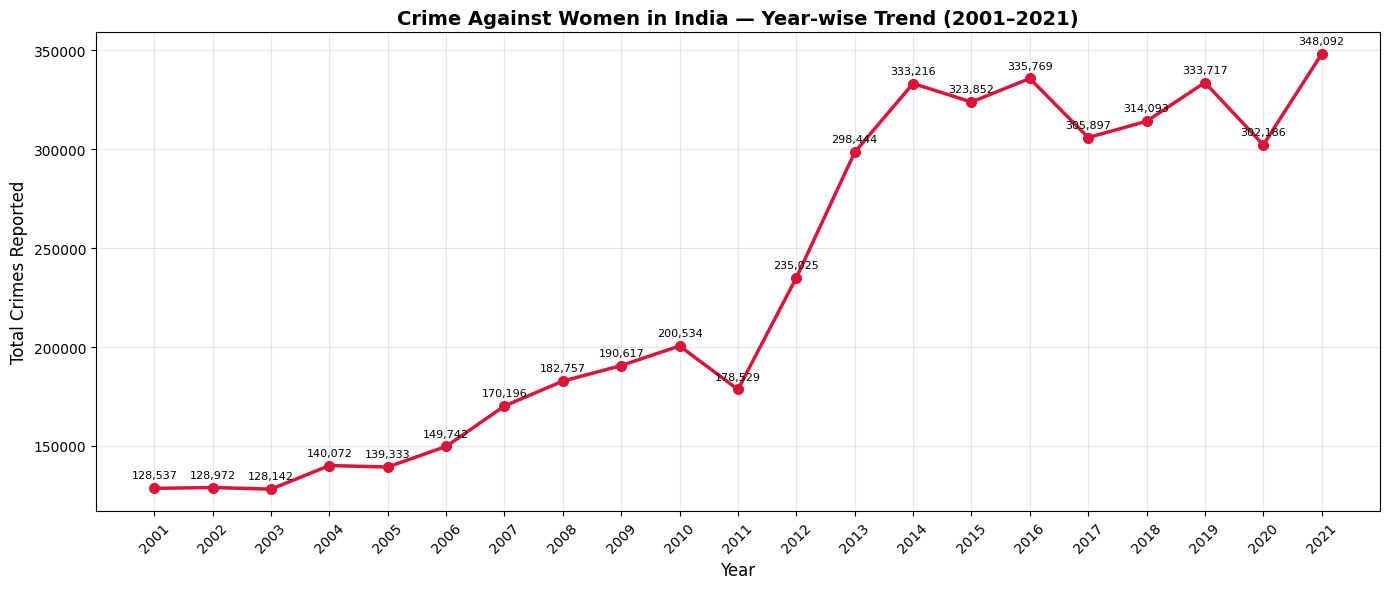

✅ Chart 1 save ho gaya!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os # Added for path manipulation and directory creation

# Year-wise total crimes
yearly = df_main.groupby('Year')['Total_Crimes'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(yearly['Year'], yearly['Total_Crimes'],
         marker='o', color='crimson', linewidth=2.5, markersize=7)

# Har point pe value dikhao
for _, row in yearly.iterrows():
    plt.text(row['Year'], row['Total_Crimes'] + 5000,
             f"{int(row['Total_Crimes']):,}", ha='center', fontsize=8)

plt.title('Crime Against Women in India — Year-wise Trend (2001–2021)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Crimes Reported', fontsize=12)
plt.xticks(yearly['Year'], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Construct the full path for saving the chart
save_path = os.path.join(folder, '..', '3_Charts', '01_yearly_trend.png')
# Extract the directory from the save_path
output_dir = os.path.dirname(save_path)

# Create the directory if it does not exist
os.makedirs(output_dir, exist_ok=True)

plt.savefig(save_path, dpi=150)
plt.show()
print("✅ Chart 1 save ho gaya!")

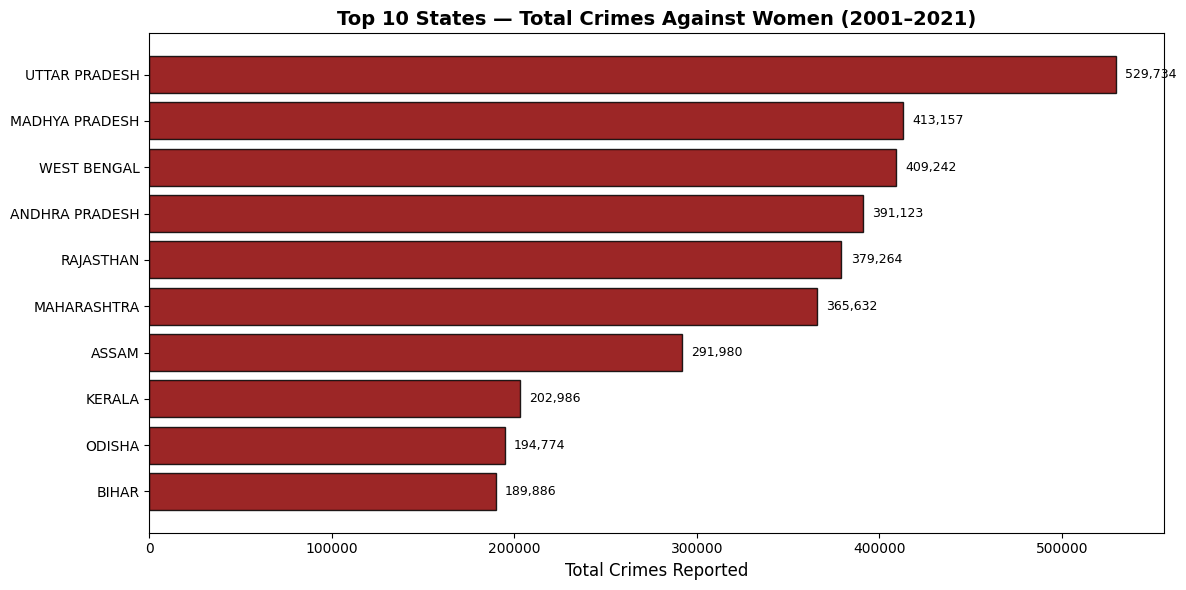

✅ Chart 2 save ho gaya!


In [ ]:
# State-wise total crimes (21 saal ka total)
state_total = df_main.groupby('State')['Total_Crimes'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
bars = plt.barh(state_total['State'], state_total['Total_Crimes'],
                color='darkred', edgecolor='black', alpha=0.85)

# Values dikhao bars ke saath
for bar, val in zip(bars, state_total['Total_Crimes']):
    plt.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va='center', fontsize=9)

plt.title('Top 10 States — Total Crimes Against Women (2001–2021)',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Crimes Reported', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(folder + '../3_Charts/02_top10_states.png', dpi=150)
plt.show()
print("✅ Chart 2 save ho gaya!")

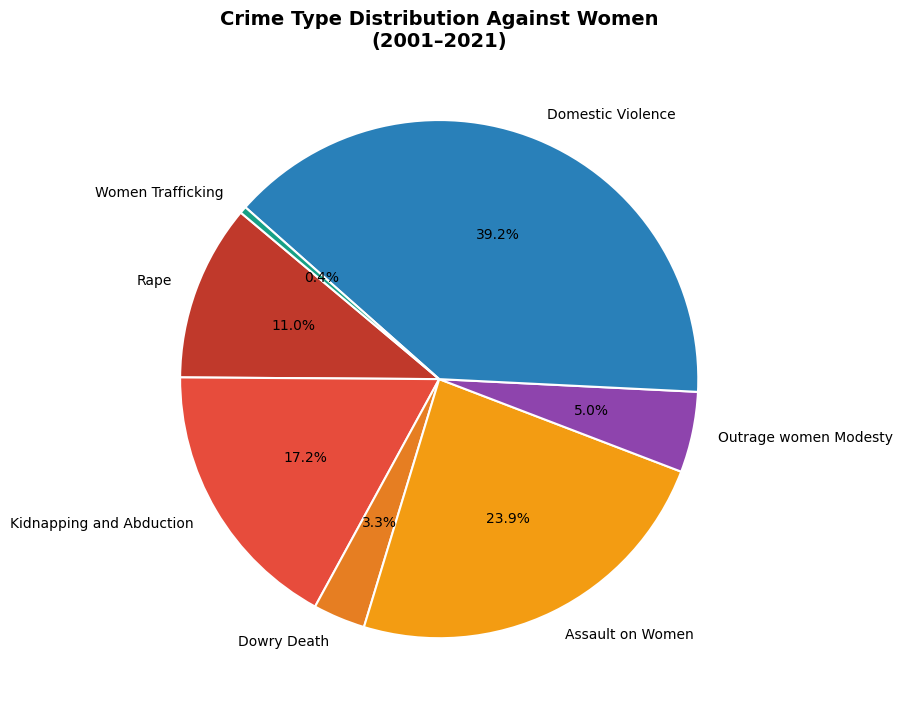

✅ Chart 3 save ho gaya!


In [ ]:
crime_cols = ['Rape', 'Kidnapping and Abduction', 'Dowry Death',
              'Assault on Women', 'Outrage women Modesty',
              'Domestic Violence', 'Women Trafficking']

crime_totals = df_main[crime_cols].sum()

colors = ['#c0392b','#e74c3c','#e67e22','#f39c12','#8e44ad','#2980b9','#16a085']

plt.figure(figsize=(9, 9))
plt.pie(crime_totals, labels=crime_cols, autopct='%1.1f%%',
        colors=colors, startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Crime Type Distribution Against Women\n(2001–2021)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(folder + '../3_Charts/03_crime_type_pie.png', dpi=150)
plt.show()
print("✅ Chart 3 save ho gaya!")

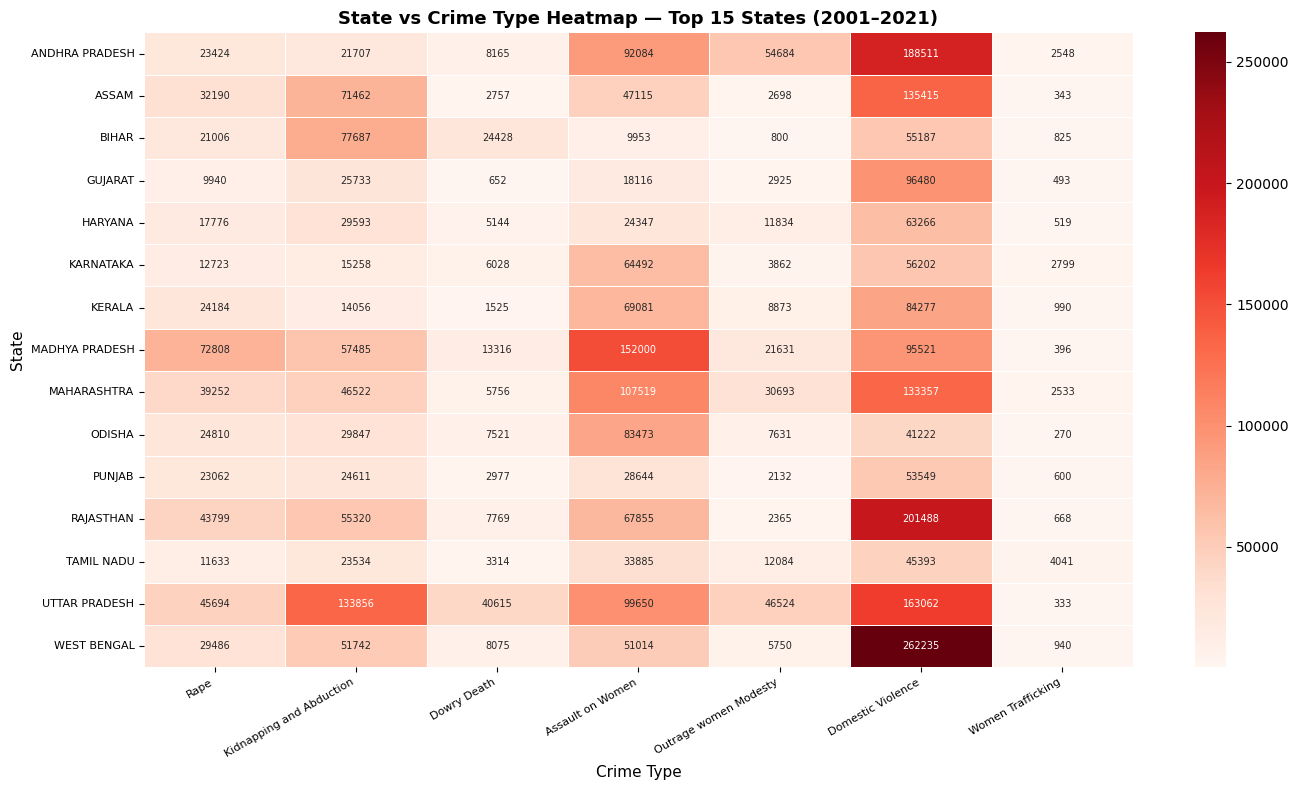

✅ Chart 4 save ho gaya!


In [ ]:
crime_cols = ['Rape', 'Kidnapping and Abduction', 'Dowry Death',
              'Assault on Women', 'Outrage women Modesty',
              'Domestic Violence', 'Women Trafficking']

# Top 15 states ka pivot banao
top15_states = df_main.groupby('State')['Total_Crimes'].sum().nlargest(15).index
df_top15 = df_main[df_main['State'].isin(top15_states)]

pivot = df_top15.groupby('State')[crime_cols].sum()

plt.figure(figsize=(14, 8))
sns.heatmap(pivot,
            cmap='Reds',
            linewidths=0.5,
            annot=True,
            fmt='.0f',
            annot_kws={'size': 7})

plt.title('State vs Crime Type Heatmap — Top 15 States (2001–2021)',
          fontsize=13, fontweight='bold')
plt.xlabel('Crime Type', fontsize=11)
plt.ylabel('State', fontsize=11)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(folder + '../3_Charts/04_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 4 save ho gaya!")

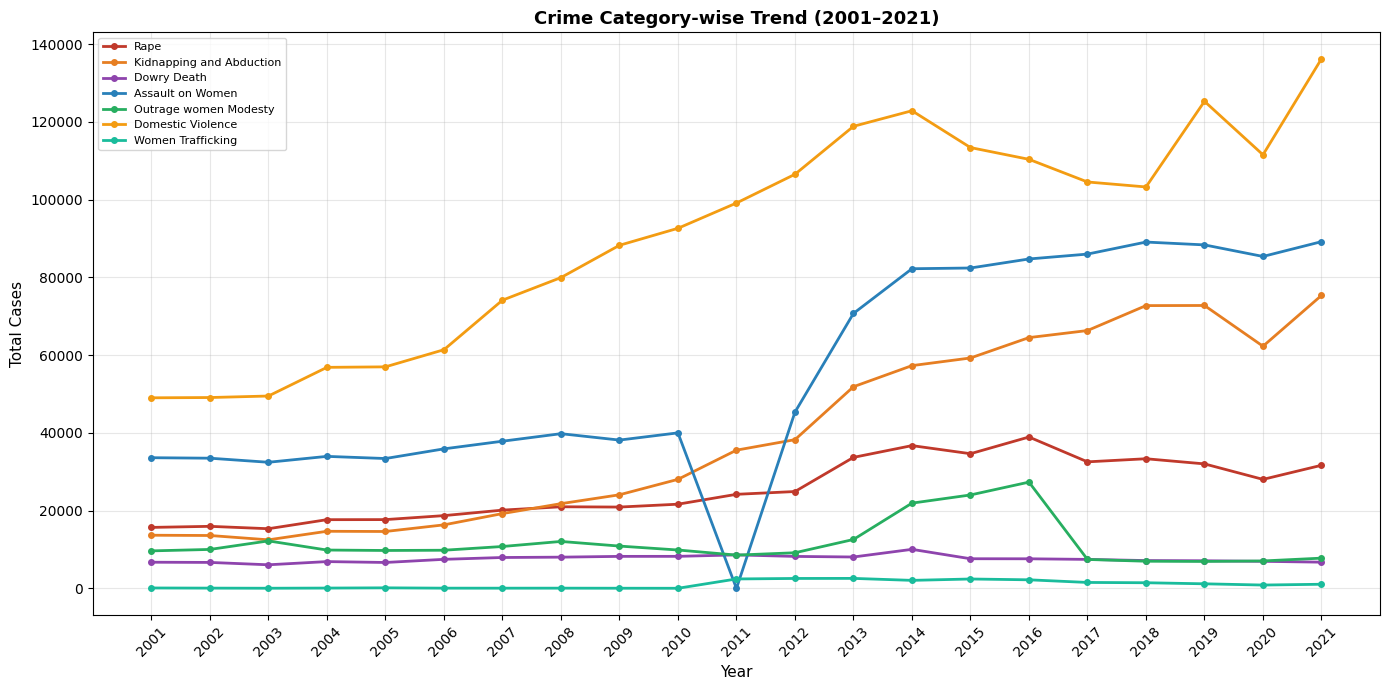

✅ Chart 5 save ho gaya!


In [ ]:
# Har crime type ka year-wise trend ek saath
yearly_crimes = df_main.groupby('Year')[crime_cols].sum()

plt.figure(figsize=(14, 7))

colors_map = {
    'Rape'                    : '#c0392b',
    'Kidnapping and Abduction': '#e67e22',
    'Dowry Death'             : '#8e44ad',
    'Assault on Women'        : '#2980b9',
    'Outrage women Modesty'   : '#27ae60',
    'Domestic Violence'       : '#f39c12',
    'Women Trafficking'       : '#1abc9c'
}

for crime in crime_cols:
    plt.plot(yearly_crimes.index, yearly_crimes[crime],
             marker='o', label=crime, linewidth=2,
             color=colors_map[crime], markersize=4)

plt.title('Crime Category-wise Trend (2001–2021)',
          fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Total Cases', fontsize=11)
plt.xticks(yearly_crimes.index, rotation=45)
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(folder + '../3_Charts/05_category_trend.png', dpi=150)
plt.show()
print("✅ Chart 5 save ho gaya!")

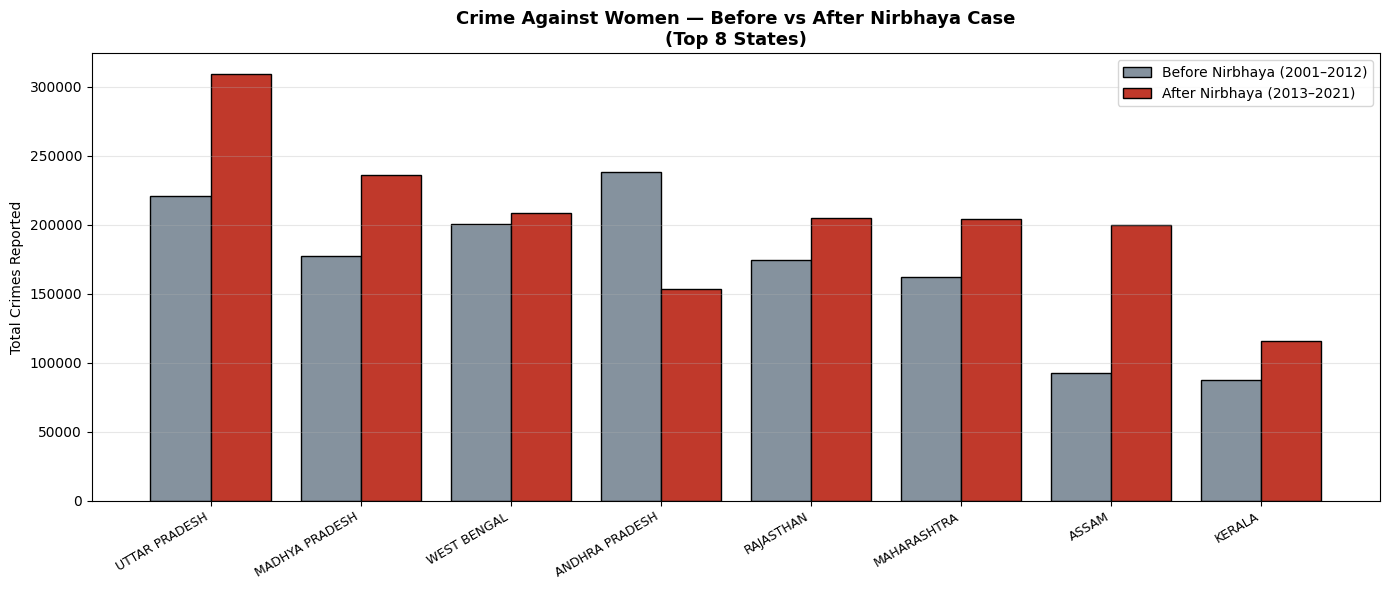

✅ Chart 6 save ho gaya!


In [ ]:
# 2012 se pehle aur baad ka comparison
df_before = df_main[df_main['Year'] <= 2012].groupby('State')['Total_Crimes'].sum()
df_after  = df_main[df_main['Year'] >  2012].groupby('State')['Total_Crimes'].sum()

# Top 8 states
top8 = df_main.groupby('State')['Total_Crimes'].sum().nlargest(8).index
before_vals = df_before[top8].values
after_vals  = df_after[top8].values
states      = list(top8)

x = range(len(states))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar([i - width/2 for i in x], before_vals, width,
               label='Before Nirbhaya (2001–2012)', color='#85929e', edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], after_vals, width,
               label='After Nirbhaya (2013–2021)', color='#c0392b', edgecolor='black')

ax.set_title('Crime Against Women — Before vs After Nirbhaya Case\n(Top 8 States)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Total Crimes Reported')
ax.set_xticks(list(x))
ax.set_xticklabels(states, rotation=30, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(folder + '../3_Charts/06_before_after_nirbhaya.png', dpi=150)
plt.show()
print("✅ Chart 6 save ho gaya!")

In [ ]:
print("="*60)
print("        KEY FINDINGS — CRIME AGAINST WOMEN")
print("="*60)

# Finding 1: Overall growth
first_year = df_main[df_main['Year'] == 2001]['Total_Crimes'].sum()
last_year  = df_main[df_main['Year'] == 2021]['Total_Crimes'].sum()
growth_pct = ((last_year - first_year) / first_year) * 100
print(f"\n📈 FINDING 1 — Overall Growth")
print(f"   2001: {first_year:,} crimes")
print(f"   2021: {last_year:,} crimes")
print(f"   Growth: {growth_pct:.1f}% in 20 years")

# Finding 2: Worst state
worst_state = df_main.groupby('State')['Total_Crimes'].sum().idxmax()
worst_val   = df_main.groupby('State')['Total_Crimes'].sum().max()
print(f"\n🗺️ FINDING 2 — Worst State")
print(f"   {worst_state} with {worst_val:,} total crimes (2001-2021)")

# Finding 3: Worst crime type
crime_cols = ['Rape','Kidnapping and Abduction','Dowry Death',
              'Assault on Women','Outrage women Modesty',
              'Domestic Violence','Women Trafficking']
worst_crime = df_main[crime_cols].sum().idxmax()
worst_crime_val = df_main[crime_cols].sum().max()
print(f"\n⚠️ FINDING 3 — Most Common Crime")
print(f"   {worst_crime}: {worst_crime_val:,} cases")

# Finding 4: Worst year
worst_year = df_main.groupby('Year')['Total_Crimes'].sum().idxmax()
worst_year_val = df_main.groupby('Year')['Total_Crimes'].sum().max()
print(f"\n📅 FINDING 4 — Worst Year")
print(f"   {worst_year} with {worst_year_val:,} crimes")

# Finding 5: Nirbhaya effect
before = df_main[df_main['Year'] <= 2012]['Total_Crimes'].sum()
after  = df_main[df_main['Year'] >  2012]['Total_Crimes'].sum()
print(f"\n⚖️ FINDING 5 — Nirbhaya Effect")
print(f"   Before 2012 (2001-2012): {before:,} crimes")
print(f"   After  2012 (2013-2021): {after:,} crimes")
print(f"   Increase: {((after-before)/before*100):.1f}%")

# Finding 6: Year with lowest crimes
best_year = df_main.groupby('Year')['Total_Crimes'].sum().idxmin()
best_val  = df_main.groupby('Year')['Total_Crimes'].sum().min()
print(f"\n✅ FINDING 6 — Lowest Crime Year")
print(f"   {best_year} with {best_val:,} crimes")

# Finding 7: Rape trend
rape_2001 = df_main[df_main['Year']==2001]['Rape'].sum()
rape_2021 = df_main[df_main['Year']==2021]['Rape'].sum()
print(f"\n🔴 FINDING 7 — Rape Cases Growth")
print(f"   2001: {rape_2001:,} | 2021: {rape_2021:,}")
print(f"   Change: {((rape_2021-rape_2001)/rape_2001*100):.1f}%")

print("\n" + "="*60)
print("✅ All findings extracted!")

        KEY FINDINGS — CRIME AGAINST WOMEN

📈 FINDING 1 — Overall Growth
   2001: 128,537 crimes
   2021: 348,092 crimes
   Growth: 170.8% in 20 years

🗺️ FINDING 2 — Worst State
   UTTAR PRADESH with 529,734 total crimes (2001-2021)

⚠️ FINDING 3 — Most Common Crime
   Domestic Violence: 1,909,978 cases

📅 FINDING 4 — Worst Year
   2021 with 348,092 crimes

⚖️ FINDING 5 — Nirbhaya Effect
   Before 2012 (2001-2012): 1,972,456 crimes
   After  2012 (2013-2021): 2,895,266 crimes
   Increase: 46.8%

✅ FINDING 6 — Lowest Crime Year
   2003 with 128,142 crimes

🔴 FINDING 7 — Rape Cases Growth
   2001: 15,694 | 2021: 31,677
   Change: 101.8%

✅ All findings extracted!


In [ ]:
all_years = list(range(2001, 2023))  # 2001 to 2022
data_years = sorted(df_main['Year'].unique())

missing = [y for y in all_years if y not in data_years]
print("Data hai in years :", data_years)
print("Missing years     :", missing)

Data hai in years : [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Missing years     : [2022]


In [ ]:
df_0112 = pd.read_csv(folder + 'Crime Against Women 2001-2012.csv')

print("Original shape:", df_0112.shape)
print(df_0112.head())

# Wide to Long format
year_cols = [str(y) for y in range(2001, 2013)]

df_0112_long = df_0112.melt(
    id_vars=['STATE/UT', 'CRIME HEAD'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Cases'
)

# Column names standardize karo
df_0112_long.rename(columns={
    'STATE/UT'  : 'State',
    'CRIME HEAD': 'Crime_Head'
}, inplace=True)

df_0112_long['Year'] = df_0112_long['Year'].astype(int)

print("\nReshaped:")
print(df_0112_long.head(10))
print("Shape:", df_0112_long.shape)

Original shape: (324, 14)
            STATE/UT CRIME HEAD  2001  2002  2003  2004  2005  2006  2007  \
0     Andhra Pradesh       RAPE   871  1002   946  1016   935  1049  1070   
1  Arunachal Pradesh       RAPE    33    38    31    42    35    37    48   
2              Assam       RAPE   817   970  1095  1171  1238  1244  1437   
3              Bihar       RAPE   888  1040   985  1390  1147  1232  1555   
4       Chhattisgarh       RAPE   959   992   898   969   990   995   982   

   2008  2009  2010  2011  2012  
0  1257  1188  1362  1442  1341  
1    42    59    47    42    46  
2  1438  1631  1721  1700  1716  
3  1302   929   795   934   927  
4   978   976  1012  1053  1034  

Reshaped:
               State Crime_Head  Year  Cases
0     Andhra Pradesh       RAPE  2001    871
1  Arunachal Pradesh       RAPE  2001     33
2              Assam       RAPE  2001    817
3              Bihar       RAPE  2001    888
4       Chhattisgarh       RAPE  2001    959
5                Goa      

In [ ]:
# 2013
df_2013 = pd.read_csv(folder + 'Crime Against Women 2013.csv')
df_2013_long = df_2013.melt(
    id_vars=['State/UTs', 'Crime Head'],
    value_vars=['2013'],
    var_name='Year',
    value_name='Cases'
)
df_2013_long.rename(columns={'State/UTs': 'State', 'Crime Head': 'Crime_Head'}, inplace=True)
df_2013_long['Year'] = df_2013_long['Year'].astype(int)
print("2013 done:", df_2013_long.shape)

# 2014
df_2014 = pd.read_csv(folder + 'Crime Against Women 2014_1.csv')
df_2014_long = df_2014.melt(
    id_vars=['States/UTs', 'Crime Head'],
    value_vars=['2014'],
    var_name='Year',
    value_name='Cases'
)
df_2014_long.rename(columns={'States/UTs': 'State', 'Crime Head': 'Crime_Head'}, inplace=True)
df_2014_long['Year'] = df_2014_long['Year'].astype(int)
print("2014 done:", df_2014_long.shape)

2013 done: (456, 4)
2014 done: (1560, 4)


In [ ]:
df_1921 = pd.read_csv(folder + 'data reported by National Crime Records Bureau during 2019 to 2021.csv')

print("Columns:", df_1921.columns.tolist())
print(df_1921.head())

df_1921_long = df_1921.melt(
    id_vars=['State/UT', 'Category'],
    value_vars=['2019', '2020', '2021'],
    var_name='Year',
    value_name='Cases'
)
df_1921_long.rename(columns={
    'State/UT': 'State',
    'Category': 'Crime_Head'
}, inplace=True)
df_1921_long['Year'] = df_1921_long['Year'].astype(int)
print("2019-2021 done:", df_1921_long.shape)

Columns: ['Sl. No.', 'Category', 'State/UT', '2019', '2020', '2021']
  Sl. No. Category           State/UT     2019   2020   2021
0       1   States     Andhra Pradesh  17746.0  17089  17752
1       2   States  Arunachal Pradesh    317.0    281    366
2       3   States              Assam  30025.0  26352  29046
3       4   States              Bihar  18587.0  15359  17950
4       5   States       Chhattisgarh   7689.0   7385   7344
2019-2021 done: (117, 4)


In [ ]:
# Saari long-format files ek list mein
all_dfs = [df_0112_long, df_2013_long, df_2014_long, df_1921_long]

# Merge karo
df_combined = pd.concat(all_dfs, ignore_index=True)

# Clean karo
df_combined['State'] = df_combined['State'].str.strip().str.upper()
df_combined['Crime_Head'] = df_combined['Crime_Head'].str.strip()
df_combined['Year'] = df_combined['Year'].astype(int)
df_combined['Cases'] = pd.to_numeric(df_combined['Cases'], errors='coerce').fillna(0).astype(int)

# Duplicate rows hatao
df_combined.drop_duplicates(inplace=True)

print("="*50)
print("FINAL MERGED DATASET")
print("="*50)
print(f"Total rows  : {len(df_combined)}")
print(f"Years       : {sorted(df_combined['Year'].unique())}")
print(f"States      : {df_combined['State'].nunique()}")
print(f"Crime Types : {df_combined['Crime_Head'].unique()}")
print(df_combined.head(10))

FINAL MERGED DATASET
Total rows  : 6021
Years       : [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2019), np.int64(2020), np.int64(2021)]
States      : 52
Crime Types : ['RAPE' 'KIDNAPPING & ABDUCTION' 'DOWRY DEATH'
 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'
 'INSULT TO THE MODESTY OF WOMEN' 'CRUELTY BY HUSBAND OR RELATIVES'
 'IMMORAL TRAFFIC(PREVENTION)ACT'
 'INDECENT REPRESENTATION OF WOMEN(PREVENTION)ACT'
 'TOTAL CRIMES AGAINST WOMEN'
 'Assault on women with intent to outrage her Modest'
 'Commission of Sati (P) Act' 'Cruelty by Husband or his relatives'
 'Dowry Deaths' 'Dowry Prohibition Act' 'Immoral Traffic (P) Act'
 'Importation of Girls from Foreign Country'
 'Indecent Representation of Women (P) Act'
 'Insult to the modesty of Women'
 'Kidnapping & Abduction of Women & Grils' 'Ra

In [ ]:
# Main merged file save karo
df_combined.to_csv(folder + 'MAIN_merged_crimes.csv', index=False)
print("✅ MAIN_merged_crimes.csv save ho gayi!")

# CrimesOnWomenData bhi save karo (ye already clean hai)
df_main.to_csv(folder + 'MAIN_CrimesOnWomen_clean.csv', index=False)
print("✅ MAIN_CrimesOnWomen_clean.csv save ho gayi!")

# Alag files alag save karo
df_cyber = pd.read_csv(folder + 'Cyber Crimes against Women during 2023.csv')
df_cyber.to_csv(folder + 'SPECIAL_cyber_crimes.csv', index=False)
print("✅ SPECIAL_cyber_crimes.csv save ho gayi!")

df_arrested = pd.read_csv(folder + 'Persons Arrested for Crime Against Women 2001-2012.csv')
df_arrested.to_csv(folder + 'SPECIAL_arrested.csv', index=False)
print("✅ SPECIAL_arrested.csv save ho gayi!")

print("\n🎉 Saari files ready hain!")

✅ MAIN_merged_crimes.csv save ho gayi!
✅ MAIN_CrimesOnWomen_clean.csv save ho gayi!
✅ SPECIAL_cyber_crimes.csv save ho gayi!
✅ SPECIAL_arrested.csv save ho gayi!

🎉 Saari files ready hain!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

drive.mount('/content/drive') # Ensure Google Drive is mounted

folder = '/content/drive/MyDrive/Crime-Project/1_Data/'

# List all files in the directory to confirm names
print("Files in the folder:")
found_files = os.listdir(folder)
for f in found_files:
    print(f"- {f}")
print("-" * 30)

# Saari district files load karo
# Check existence for each file before loading
file1 = 'District-wise crimes committed against Women during 2001-2012.csv'
file2 = 'District-wise crimes committed against Women during 2013.csv'
file3 = 'District-wise Crimes committed against Women during 2014.csv' # Note: 'Crimes' (capital C)
file4 = 'District Area-wise Crimes committed against Women during 2015.csv'
file5 = 'NCRB District Wise Crime Against Women 2022.csv'

# Helper function to load with check
def load_csv_with_check(filepath):
    full_path = os.path.join(folder, filepath)
    if not os.path.exists(full_path):
        print(f"❌ Error: File not found: '{filepath}'")
        return None
    try:
        df = pd.read_csv(full_path)
        print(f"✅ Loaded: '{filepath}' (Shape: {df.shape})")
        return df
    except Exception as e:
        print(f"❌ Error loading '{filepath}': {e}")
        return None

df_d1 = load_csv_with_check(file1)
df_d2 = load_csv_with_check(file2)
df_d3 = load_csv_with_check(file3)
df_d4 = load_csv_with_check(file4)
df_d5 = load_csv_with_check(file5)

print("\n✅ Saari files load ho gayi (jinka path sahi tha)!")
if df_d1 is not None:
    print(f"2001-2012 : {df_d1.shape}")
if df_d2 is not None:
    print(f"2013      : {df_d2.shape}")
if df_d3 is not None:
    print(f"2014      : {df_d3.shape}")
if df_d4 is not None:
    print(f"2015      : {df_d4.shape}")
if df_d5 is not None:
    print(f"2022      : {df_d5.shape}")

Mounted at /content/drive
Files in the folder:
- Crime against Women (2001-2022).csv
- Crime Against Women 2001-2012.csv
- Crime Against Women 2013.csv
- Crime Against Women 2014_1.csv
- NCRB District Wise Crime Against Women 2022.csv
- Persons Arrested for Crime Against Women 2001-2012.csv
- data reported by National Crime Records Bureau during 2019 to 2021.csv
- Crime Head-wise and State-UT-wise (IPC) Crimes and (SLL) against Women during 2023.csv
- Cyber Crimes against Women during 2023.csv
- State & UT-wise Cases Reported (I), Victims(V) & Rate (R) of Crimes Committed Against Women During 2015.csv
- District-wise crimes committed against Women during 2013.csv
- District Area-wise Crimes committed against Women during 2015.csv
- District-wise Crimes committed against Women during 2014.csv
- District-wise crimes committed against Women during 2001-2012.csv
- CrimesOnWomenData.csv
- MAIN_merged_crimes.csv
- MAIN_CrimesOnWomen_clean.csv
- SPECIAL_cyber_crimes.csv
- SPECIAL_arrested.csv

In [ ]:
# ── 2001-2012 ──────────────────────────────────────────
df_d1_clean = df_d1.copy()
df_d1_clean.rename(columns={'STATE/UT': 'State', 'DISTRICT': 'District'}, inplace=True)

# Individual crime columns sum karke Total banao
crime_cols_d1 = ['Rape', 'Kidnapping and Abduction', 'Dowry Deaths',
                 'Assault on women with intent to outrage her modesty',
                 'Insult to modesty of Women',
                 'Cruelty by Husband or his Relatives', 'Importation of Girls']

df_d1_clean['Total_Crimes'] = df_d1_clean[crime_cols_d1].sum(axis=1)

print("2001-2012 ready:", df_d1_clean.shape)

# ── 2013 ───────────────────────────────────────────────
df_d2_clean = df_d2.copy()
df_d2_clean.rename(columns={
    'STATE/UT' : 'State',
    'DISTRICT' : 'District'
}, inplace=True)
df_d2_clean['Year'] = 2013
crime_cols_d2 = ['Rape', 'Kidnapping and Abduction', 'Dowry Deaths',
                 'Assault on women with intent to outrage her modesty',
                 'Insult to modesty of Women',
                 'Cruelty by Husband or his Relatives', 'Importation of Girls']
df_d2_clean['Total_Crimes'] = df_d2_clean[crime_cols_d2].sum(axis=1)
print("2013 ready:", df_d2_clean.shape)

# ── 2014 ───────────────────────────────────────────────
df_d3_clean = df_d3.copy()
df_d3_clean.rename(columns={
    'State/ UT'    : 'State',
    'District/ Area': 'District'
}, inplace=True)
df_d3_clean['Year'] = 2014
df_d3_clean['Total_Crimes'] = df_d3_clean['Total Crimes against Women']
print("2014 ready:", df_d3_clean.shape)

# ── 2015 ───────────────────────────────────────────────
df_d4_clean = df_d4.copy()
df_d4_clean.rename(columns={
    'State/ UT'    : 'State',
    'District/ Area': 'District'
}, inplace=True)
df_d4_clean['Year'] = 2015
df_d4_clean['Total_Crimes'] = df_d4_clean['Total Crimes against Women']
print("2015 ready:", df_d4_clean.shape)

# ── 2022 ───────────────────────────────────────────────
df_d5_clean = df_d5.copy()
df_d5_clean.rename(columns={
    'State/UT': 'State',
    'District': 'District'
}, inplace=True)
df_d5_clean['Year'] = 2022
df_d5_clean['Total_Crimes'] = df_d5_clean['Total Crime against Women (IPC+SLL) - Col. ( 54)']
print("2022 ready:", df_d5_clean.shape)

print("\n✅ Saari files clean ho gayi!")

2001-2012 ready: (9017, 11)
2013 ready: (823, 11)
2014 ready: (837, 20)
2015 ready: (853, 20)
2022 ready: (970, 57)

✅ Saari files clean ho gayi!


In [ ]:
# Common columns select karo
keep_cols = ['State', 'District', 'Year', 'Total_Crimes']

dfs_district = []
for df, name in [(df_d1_clean, '2001-2012'),
                 (df_d2_clean, '2013'),
                 (df_d3_clean, '2014'),
                 (df_d4_clean, '2015'),
                 (df_d5_clean, '2022')]:
    temp = df[keep_cols].copy()
    temp['State']    = temp['State'].str.strip().str.upper()
    temp['District'] = temp['District'].str.strip().str.upper()
    temp['Year']     = temp['Year'].astype(int)
    temp['Total_Crimes'] = pd.to_numeric(
        temp['Total_Crimes'], errors='coerce').fillna(0).astype(int)
    dfs_district.append(temp)
    print(f"✅ {name}: {len(temp)} rows")

df_district = pd.concat(dfs_district, ignore_index=True)
df_district.drop_duplicates(inplace=True)

print(f"\n🎉 Final District Dataset:")
print(f"   Rows     : {len(df_district)}")
print(f"   Districts: {df_district['District'].nunique()}")
print(f"   States   : {df_district['State'].nunique()}")
print(f"   Years    : {sorted(df_district['Year'].unique())}")

# Save karo
df_district.to_csv(folder + 'CLEAN_district_data.csv', index=False)
print("\n✅ CLEAN_district_data.csv save ho gayi!")

✅ 2001-2012: 9017 rows
✅ 2013: 823 rows
✅ 2014: 837 rows
✅ 2015: 853 rows
✅ 2022: 970 rows

🎉 Final District Dataset:
   Rows     : 12500
   Districts: 1145
   States   : 44
   Years    : [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2022)]

✅ CLEAN_district_data.csv save ho gayi!


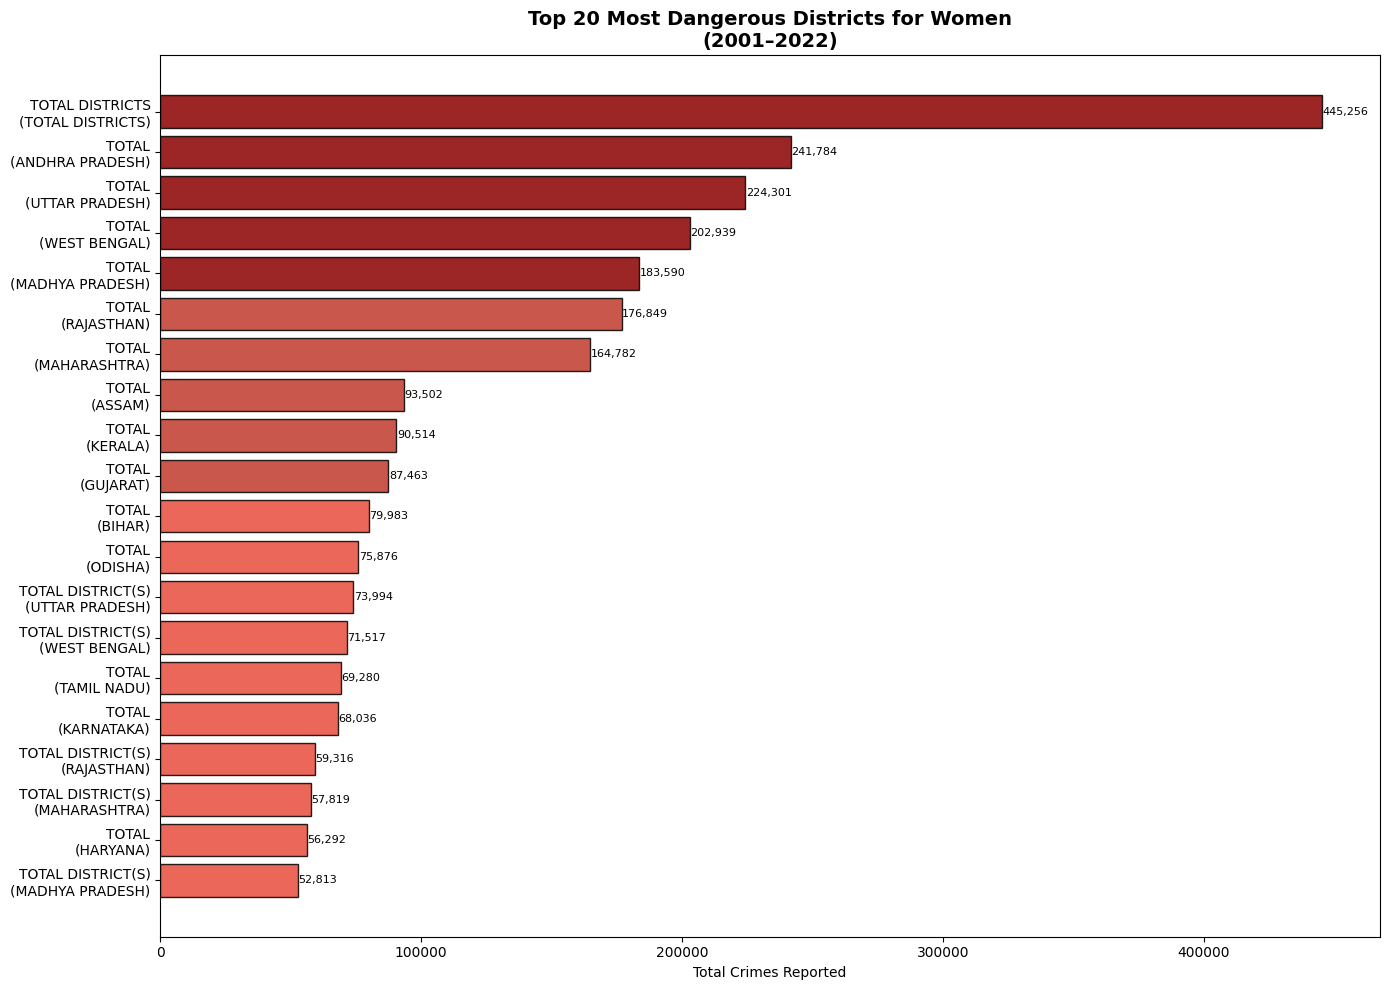

✅ Chart 7 save ho gaya!


In [ ]:
# Top 20 districts overall
top20_dist = df_district.groupby(['State','District'])['Total_Crimes']\
             .sum().nlargest(20).reset_index()

# Label: District (State)
top20_dist['Label'] = top20_dist['District'] + '\n(' + top20_dist['State'] + ')'

plt.figure(figsize=(14, 10))
colors = ['#8B0000' if i < 5 else '#c0392b' if i < 10
          else '#e74c3c' for i in range(20)]

bars = plt.barh(top20_dist['Label'], top20_dist['Total_Crimes'],
                color=colors, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, top20_dist['Total_Crimes']):
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va='center', fontsize=8)

plt.title('Top 20 Most Dangerous Districts for Women\n(2001–2022)',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Crimes Reported')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(folder + '../3_Charts/07_top20_districts.png', dpi=150)
plt.show()
print("✅ Chart 7 save ho gaya!")

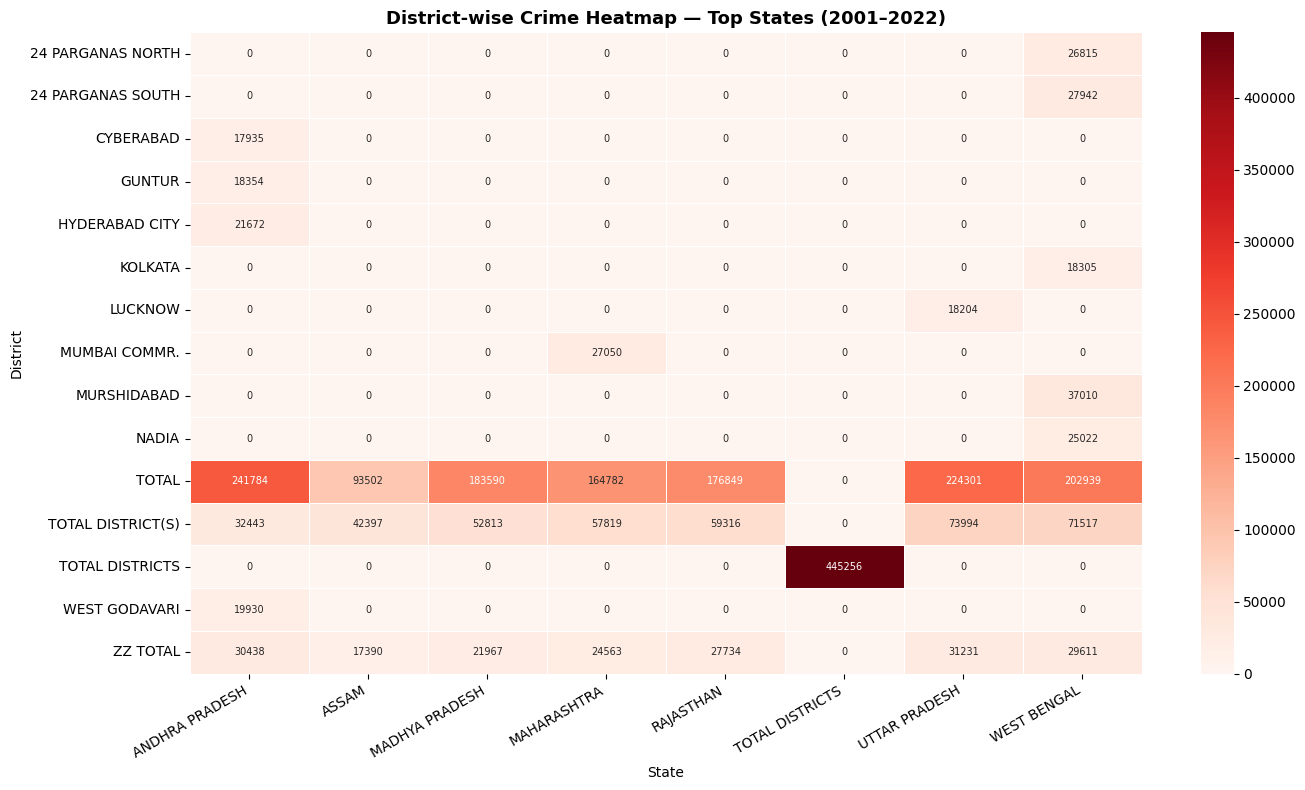

✅ Chart 8 save ho gaya!


In [ ]:
# Top 8 states ke top 5 districts
top8_states = df_district.groupby('State')['Total_Crimes']\
              .sum().nlargest(8).index

df_top8 = df_district[df_district['State'].isin(top8_states)]

# Har state ke top 5 districts
top_dist_per_state = df_top8.groupby(['State','District'])['Total_Crimes']\
                    .sum().reset_index()

# Pivot banao
pivot_dist = top_dist_per_state.pivot_table(
    index='District', columns='State',
    values='Total_Crimes', aggfunc='sum'
).fillna(0)

# Top 15 districts filter
top15_idx = top_dist_per_state.groupby('District')['Total_Crimes']\
            .sum().nlargest(15).index
pivot_dist = pivot_dist.loc[pivot_dist.index.isin(top15_idx)]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_dist, cmap='Reds', linewidths=0.5,
            annot=True, fmt='.0f', annot_kws={'size': 7})
plt.title('District-wise Crime Heatmap — Top States (2001–2022)',
          fontsize=13, fontweight='bold')
plt.xlabel('State')
plt.ylabel('District')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(folder + '../3_Charts/08_district_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 8 save ho gaya!")

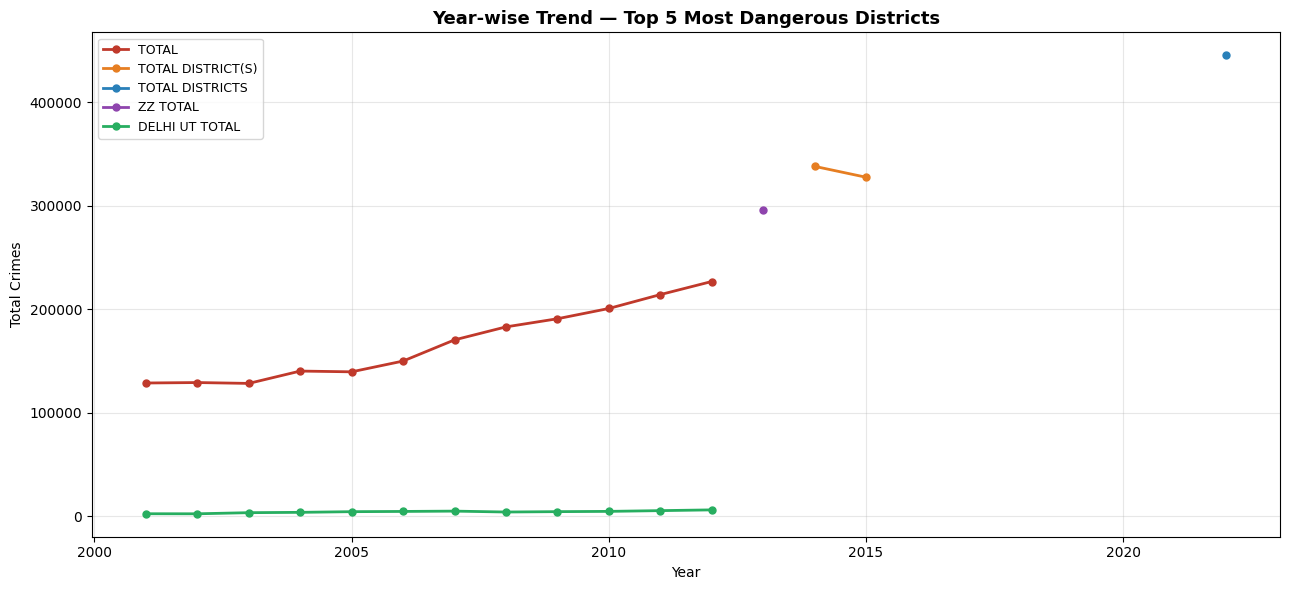

✅ Chart 9 save ho gaya!


In [ ]:
# Top 5 districts
top5_dist = df_district.groupby('District')['Total_Crimes']\
            .sum().nlargest(5).index

df_top5 = df_district[df_district['District'].isin(top5_dist)]
dist_yearly = df_top5.groupby(['Year','District'])['Total_Crimes']\
              .sum().reset_index()

plt.figure(figsize=(13, 6))
colors_d = ['#c0392b','#e67e22','#2980b9','#8e44ad','#27ae60']

for i, dist in enumerate(top5_dist):
    data = dist_yearly[dist_yearly['District'] == dist]
    plt.plot(data['Year'], data['Total_Crimes'],
             marker='o', label=dist, linewidth=2,
             color=colors_d[i], markersize=5)

plt.title('Year-wise Trend — Top 5 Most Dangerous Districts',
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Crimes')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(folder + '../3_Charts/09_district_trend.png', dpi=150)
plt.show()
print("✅ Chart 9 save ho gaya!")

In [ ]:
# Arrested file load karo
df_arrested = pd.read_csv(folder + 'Persons Arrested for Crime Against Women 2001-2012.csv')

print("Shape:", df_arrested.shape)
print("Columns:", df_arrested.columns.tolist())
print("\nPehli 5 rows:")
df_arrested.head()

Shape: (456, 14)
Columns: ['STATE/UT', 'CRIME HEAD', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012']

Pehli 5 rows:


,STATE/UT,CRIME HEAD,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012
0,ANDHRA PRADESH,RAPE,1150,1340,1237,1443,1415,1360,1436,1531,1487,1761,1758,1664
1,ARUNACHAL PRADESH,RAPE,51,61,35,56,38,40,57,37,60,49,47,47
2,ASSAM,RAPE,928,1019,1188,1233,1406,1290,1477,1445,1644,1629,1470,1626
3,BIHAR,RAPE,1400,1304,1120,1157,1455,1451,1816,1464,1086,892,1185,1327
4,CHHATTISGARH,RAPE,1134,1214,1020,1144,1107,1211,1146,1108,1128,1198,1257,1214


In [ ]:
# Wide to Long format
year_cols = [str(y) for y in range(2001, 2013)]

df_arr_long = df_arrested.melt(
    id_vars=['STATE/UT', 'CRIME HEAD'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Persons_Arrested'
)

df_arr_long.rename(columns={
    'STATE/UT'  : 'State',
    'CRIME HEAD': 'Crime_Head'
}, inplace=True)

df_arr_long['Year']             = df_arr_long['Year'].astype(int)
df_arr_long['State']            = df_arr_long['State'].str.strip().str.upper()
df_arr_long['Persons_Arrested'] = pd.to_numeric(
    df_arr_long['Persons_Arrested'], errors='coerce').fillna(0).astype(int)

print("✅ Reshaped:")
print(f"   Rows        : {len(df_arr_long)}")
print(f"   States      : {df_arr_long['State'].nunique()}")
print(f"   Crime Types : {df_arr_long['Crime_Head'].unique()}")

# Save karo
df_arr_long.to_csv(folder + 'CLEAN_arrested_data.csv', index=False)
print("\n✅ CLEAN_arrested_data.csv save ho gayi!")

✅ Reshaped:
   Rows        : 5472
   States      : 38
   Crime Types : ['RAPE' 'KIDNAPPING AND ABDUCTION' 'DOWRY DEATHS'
 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'
 'INSULT TO THE MODESTY OF WOMEN'
 'CRUELTY BY HUSBAND OR HIS RELATIVES (IPC SECTION 498A)'
 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRY' 'IMMORAL TRAFFIC (P) ACT'
 'DOWRY PROHIBITION ACT' 'INDECENT REPRESENTATION OF WOMEN (P) ACT'
 'COMMISSION OF SATI (P) ACT' 'TOTAL CRIMES AGAINST WOMEN']

✅ CLEAN_arrested_data.csv save ho gayi!


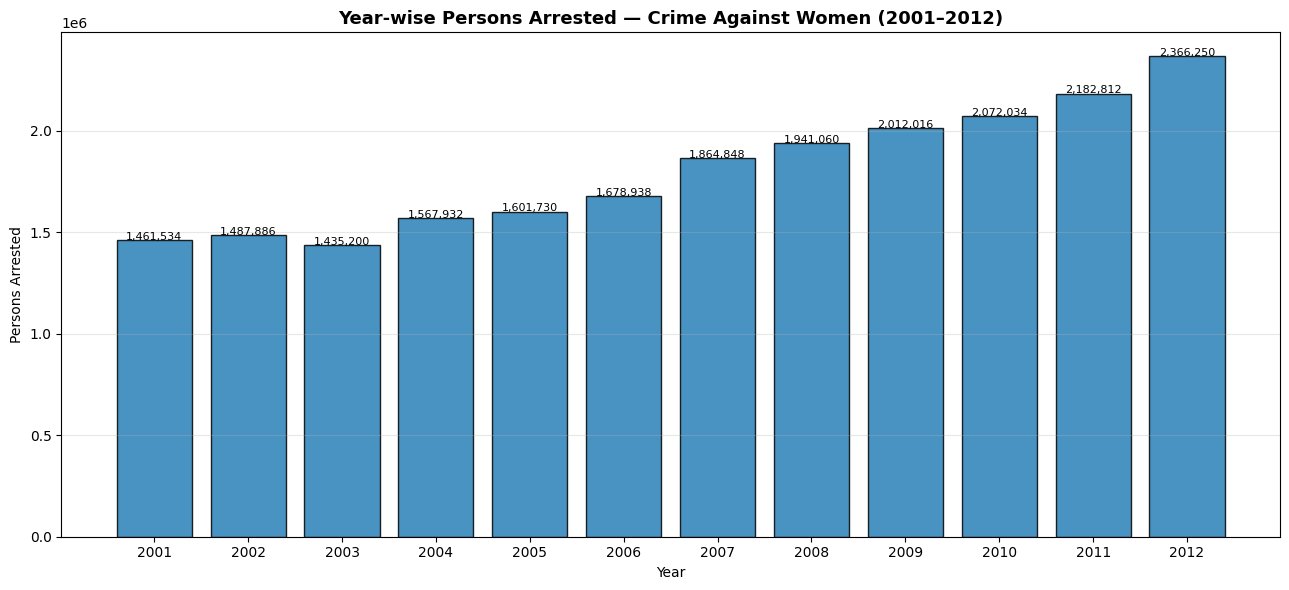

✅ Chart 10 save ho gaya!


In [ ]:
yearly_arr = df_arr_long.groupby('Year')['Persons_Arrested'].sum().reset_index()

plt.figure(figsize=(13, 6))
plt.bar(yearly_arr['Year'], yearly_arr['Persons_Arrested'],
        color='#2980b9', edgecolor='black', alpha=0.85)

for i, row in yearly_arr.iterrows():
    plt.text(row['Year'], row['Persons_Arrested'] + 500,
             f"{int(row['Persons_Arrested']):,}",
             ha='center', fontsize=8)

plt.title('Year-wise Persons Arrested — Crime Against Women (2001–2012)',
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Persons Arrested')
plt.xticks(yearly_arr['Year'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(folder + '../3_Charts/10_arrests_trend.png', dpi=150)
plt.show()
print("✅ Chart 10 save ho gaya!")

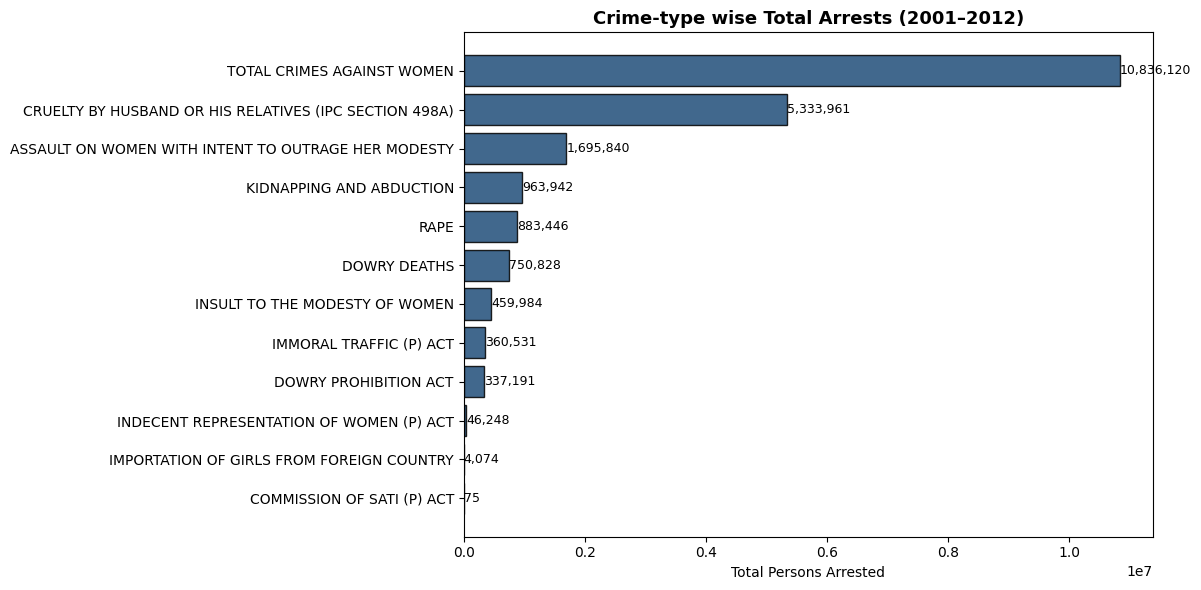

✅ Chart 11 save ho gaya!


In [ ]:
crime_arr = df_arr_long.groupby('Crime_Head')['Persons_Arrested']\
            .sum().sort_values(ascending=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(crime_arr.index, crime_arr.values,
                color='#1F4E79', edgecolor='black', alpha=0.85)

for bar, val in zip(bars, crime_arr.values):
    plt.text(bar.get_width() + 200,
             bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va='center', fontsize=9)

plt.title('Crime-type wise Total Arrests (2001–2012)',
          fontsize=13, fontweight='bold')
plt.xlabel('Total Persons Arrested')
plt.tight_layout()
plt.savefig(folder + '../3_Charts/11_crime_arrests.png', dpi=150)
plt.show()
print("✅ Chart 11 save ho gaya!")

Justice Rate by Year:
    Year  Total_Crimes  Persons_Arrested  Justice_Rate
0   2001        128537           1461534        1137.1
1   2002        128972           1487886        1153.7
2   2003        128142           1435200        1120.0
3   2004        140072           1567932        1119.4
4   2005        139333           1601730        1149.6
5   2006        149742           1678938        1121.2
6   2007        170196           1864848        1095.7
7   2008        182757           1941060        1062.1
8   2009        190617           2012016        1055.5
9   2010        200534           2072034        1033.3
10  2011        178529           2182812        1222.7
11  2012        235025           2366250        1006.8


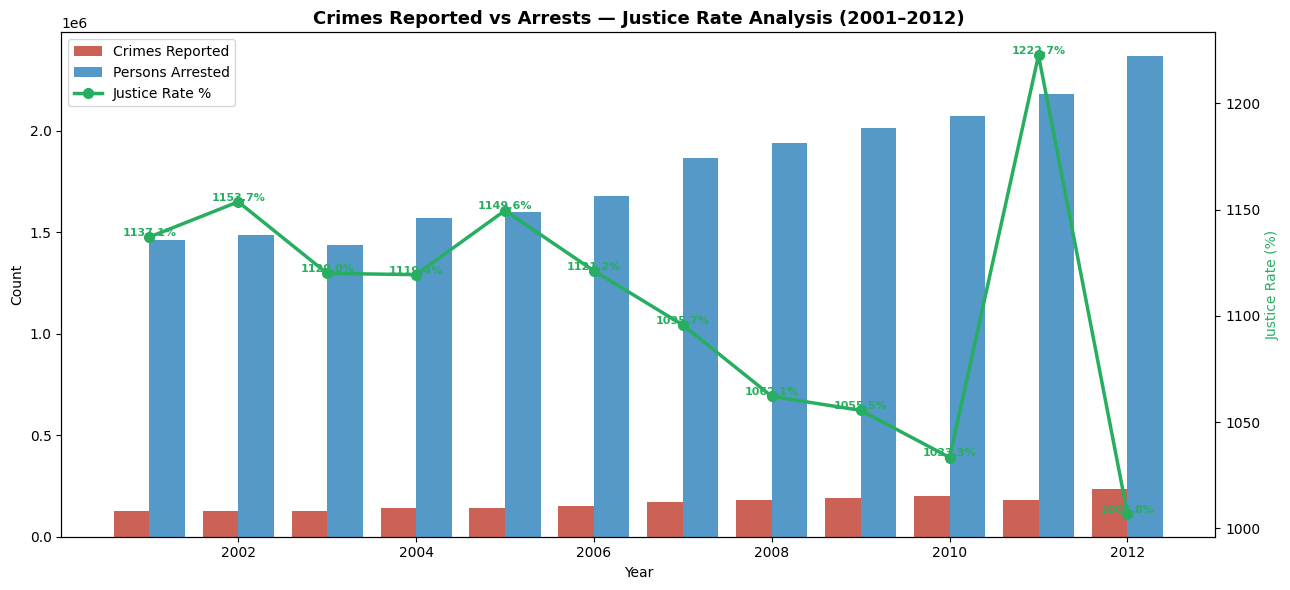

✅ Chart 12 save ho gaya!


In [ ]:
import pandas as pd

# Ensure df_main is loaded if the kernel was restarted
df_main = pd.read_csv(folder + 'CLEAN_main_data.csv')

# Main data se 2001-2012 nikalo
df_crimes_0112 = df_main[
    (df_main['Year'] >= 2001) & (df_main['Year'] <= 2012)
].groupby('Year')['Total_Crimes'].sum().reset_index()

# Arrests yearly
df_arr_yearly = df_arr_long.groupby('Year')['Persons_Arrested']\
                .sum().reset_index()

# Merge karo
df_justice = pd.merge(df_crimes_0112, df_arr_yearly, on='Year')
df_justice['Justice_Rate'] = (
    df_justice['Persons_Arrested'] / df_justice['Total_Crimes'] * 100
).round(1)

print("Justice Rate by Year:")
print(df_justice[['Year','Total_Crimes','Persons_Arrested','Justice_Rate']])

# Chart banao
fig, ax1 = plt.subplots(figsize=(13, 6))

# Bars — crimes
ax1.bar(df_justice['Year'] - 0.2, df_justice['Total_Crimes'],
        width=0.4, color='#c0392b', label='Crimes Reported', alpha=0.8)

# Bars — arrests
ax1.bar(df_justice['Year'] + 0.2, df_justice['Persons_Arrested'],
        width=0.4, color='#2980b9', label='Persons Arrested', alpha=0.8)

# Line — justice rate
ax2 = ax1.twinx()
ax2.plot(df_justice['Year'], df_justice['Justice_Rate'],
         color='#27ae60', marker='o', linewidth=2.5,
         markersize=7, label='Justice Rate %')

for _, row in df_justice.iterrows():
    ax2.text(row['Year'], row['Justice_Rate'] + 0.5,
             f"{row['Justice_Rate']}%",
             ha='center', fontsize=8, color='#27ae60', fontweight='bold')

ax1.set_xlabel('Year')
ax1.set_ylabel('Count', color='black')
ax2.set_ylabel('Justice Rate (%)', color='#27ae60')
ax1.set_title('Crimes Reported vs Arrests — Justice Rate Analysis (2001–2012)',
              fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(folder + '../3_Charts/12_justice_rate.png', dpi=150)
plt.show()
print("✅ Chart 12 save ho gaya!")

In [ ]:
print("="*55)
print("   ARRESTS & JUSTICE ANALYSIS — KEY FINDINGS")
print("="*55)

total_crimes  = df_justice['Total_Crimes'].sum()
total_arrests = df_justice['Persons_Arrested'].sum()
avg_justice   = df_justice['Justice_Rate'].mean()

print(f"\n🔴 Total Crimes (2001-2012)  : {total_crimes:,}")
print(f"👮 Total Arrests (2001-2012) : {total_arrests:,}")
print(f"⚖️  Avg Justice Rate          : {avg_justice:.1f}%")

best  = df_justice.loc[df_justice['Justice_Rate'].idxmax()]
worst = df_justice.loc[df_justice['Justice_Rate'].idxmin()]
print(f"\n✅ Best  year : {int(best['Year'])} — {best['Justice_Rate']}%")
print(f"❌ Worst year : {int(worst['Year'])} — {worst['Justice_Rate']}%")

# Crime type wise arrest
top_arrested = df_arr_long.groupby('Crime_Head')['Persons_Arrested']\
               .sum().idxmax()
least_arrested = df_arr_long.groupby('Crime_Head')['Persons_Arrested']\
                 .sum().idxmin()
print(f"\n🔺 Most arrested for  : {top_arrested}")
print(f"🔻 Least arrested for : {least_arrested}")
print("="*55)

   ARRESTS & JUSTICE ANALYSIS — KEY FINDINGS

🔴 Total Crimes (2001-2012)  : 1,972,456
👮 Total Arrests (2001-2012) : 21,672,240
⚖️  Avg Justice Rate          : 1106.4%

✅ Best  year : 2011 — 1222.7%
❌ Worst year : 2012 — 1006.8%

🔺 Most arrested for  : TOTAL CRIMES AGAINST WOMEN
🔻 Least arrested for : COMMISSION OF SATI (P) ACT


In [ ]:
# Problem dekho — crime heads kya hain
print("Crime Heads in Arrested file:")
print(df_arr_long['Crime_Head'].unique())

Crime Heads in Arrested file:
['RAPE' 'KIDNAPPING AND ABDUCTION' 'DOWRY DEATHS'
 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'
 'INSULT TO THE MODESTY OF WOMEN'
 'CRUELTY BY HUSBAND OR HIS RELATIVES (IPC SECTION 498A)'
 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRY' 'IMMORAL TRAFFIC (P) ACT'
 'DOWRY PROHIBITION ACT' 'INDECENT REPRESENTATION OF WOMEN (P) ACT'
 'COMMISSION OF SATI (P) ACT' 'TOTAL CRIMES AGAINST WOMEN']


In [ ]:
# "TOTAL" wali rows hatao — woh aggregate rows hain
df_arr_clean = df_arr_long[
    ~df_arr_long['Crime_Head'].str.upper().str.contains('TOTAL')
].copy()

print(f"Pehle rows : {len(df_arr_long)}")
print(f"Baad rows  : {len(df_arr_clean)}")
print(f"\nClean Crime Heads:\n{df_arr_clean['Crime_Head'].unique()}")

Pehle rows : 5472
Baad rows  : 5016

Clean Crime Heads:
['RAPE' 'KIDNAPPING AND ABDUCTION' 'DOWRY DEATHS'
 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'
 'INSULT TO THE MODESTY OF WOMEN'
 'CRUELTY BY HUSBAND OR HIS RELATIVES (IPC SECTION 498A)'
 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRY' 'IMMORAL TRAFFIC (P) ACT'
 'DOWRY PROHIBITION ACT' 'INDECENT REPRESENTATION OF WOMEN (P) ACT'
 'COMMISSION OF SATI (P) ACT']


In [ ]:
# Yearly arrests recalculate karo
df_arr_yearly = df_arr_clean.groupby('Year')['Persons_Arrested']\
                .sum().reset_index()

# Crimes 2001-2012
df_crimes_0112 = df_main[
    (df_main['Year'] >= 2001) & (df_main['Year'] <= 2012)
].groupby('Year')['Total_Crimes'].sum().reset_index()

# Merge
df_justice = pd.merge(df_crimes_0112, df_arr_yearly, on='Year')
df_justice['Justice_Rate'] = (
    df_justice['Persons_Arrested'] / df_justice['Total_Crimes'] * 100
).round(1)

# Findings print karo
print("="*55)
print("   ARRESTS & JUSTICE ANALYSIS — CORRECTED")
print("="*55)
total_crimes  = df_justice['Total_Crimes'].sum()
total_arrests = df_justice['Persons_Arrested'].sum()
avg_justice   = df_justice['Justice_Rate'].mean()

print(f"\n🔴 Total Crimes  (2001-2012) : {total_crimes:,}")
print(f"👮 Total Arrests (2001-2012) : {total_arrests:,}")
print(f"⚖️  Avg Justice Rate          : {avg_justice:.1f}%")

best  = df_justice.loc[df_justice['Justice_Rate'].idxmax()]
worst = df_justice.loc[df_justice['Justice_Rate'].idxmin()]
print(f"\n✅ Best  year : {int(best['Year'])} — {best['Justice_Rate']}%")
print(f"❌ Worst year : {int(worst['Year'])} — {worst['Justice_Rate']}%")
print("="*55)
print(df_justice[['Year','Total_Crimes','Persons_Arrested','Justice_Rate']])

   ARRESTS & JUSTICE ANALYSIS — CORRECTED

🔴 Total Crimes  (2001-2012) : 1,972,456
👮 Total Arrests (2001-2012) : 10,836,120
⚖️  Avg Justice Rate          : 553.2%

✅ Best  year : 2011 — 611.3%
❌ Worst year : 2012 — 503.4%
    Year  Total_Crimes  Persons_Arrested  Justice_Rate
0   2001        128537            730767         568.5
1   2002        128972            743943         576.8
2   2003        128142            717600         560.0
3   2004        140072            783966         559.7
4   2005        139333            800865         574.8
5   2006        149742            839469         560.6
6   2007        170196            932424         547.9
7   2008        182757            970530         531.0
8   2009        190617           1006008         527.8
9   2010        200534           1036017         516.6
10  2011        178529           1091406         611.3
11  2012        235025           1183125         503.4


In [ ]:
# Arrested file ka raw data dekho
df_arrested = pd.read_csv(folder + 'Persons Arrested for Crime Against Women 2001-2012.csv')

print("Total rows:", len(df_arrested))
print("\nAll unique STATE/UT values:")
print(df_arrested['STATE/UT'].unique())
print("\nAll unique CRIME HEAD values:")
print(df_arrested['CRIME HEAD'].unique())
print("\nPehli 20 rows:")
print(df_arrested.head(20).to_string())

Total rows: 456

All unique STATE/UT values:
['ANDHRA PRADESH' 'ARUNACHAL PRADESH' 'ASSAM' 'BIHAR' 'CHHATTISGARH' 'GOA'
 'GUJARAT' 'HARYANA' 'HIMACHAL PRADESH' 'JAMMU & KASHMIR' 'JHARKHAND'
 'KARNATAKA' 'KERALA' 'MADHYA PRADESH' 'MAHARASHTRA' 'MANIPUR' 'MEGHALAYA'
 'MIZORAM' 'NAGALAND' 'ODISHA' 'PUNJAB' 'RAJASTHAN' 'SIKKIM' 'TAMIL NADU'
 'TRIPURA' 'UTTAR PRADESH' 'UTTARAKHAND' 'WEST BENGAL' 'TOTAL (STATES)'
 'A & N ISLANDS' 'CHANDIGARH' 'D & N HAVELI' 'DAMAN & DIU' 'DELHI'
 'LAKSHADWEEP' 'PUDUCHERRY' 'TOTAL (UTs)' 'TOTAL (ALL-INDIA)']

All unique CRIME HEAD values:
['RAPE' 'KIDNAPPING AND ABDUCTION' 'DOWRY DEATHS'
 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'
 'INSULT TO THE MODESTY OF WOMEN'
 'CRUELTY BY HUSBAND OR HIS RELATIVES (IPC SECTION 498A)'
 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRY' 'IMMORAL TRAFFIC (P) ACT'
 'DOWRY PROHIBITION ACT' 'INDECENT REPRESENTATION OF WOMEN (P) ACT'
 'COMMISSION OF SATI (P) ACT' 'TOTAL CRIMES AGAINST WOMEN']

Pehli 20 rows:
             STA

In [ ]:
# Step 1: TOTAL rows hatao STATE/UT se
df_arr_clean = df_arr_long[
    ~df_arr_long['State'].str.upper().str.contains('TOTAL')
].copy()

# Step 2: TOTAL rows hatao CRIME HEAD se bhi
df_arr_clean = df_arr_clean[
    ~df_arr_clean['Crime_Head'].str.upper().str.contains('TOTAL')
].copy()

print(f"Pehle rows : {len(df_arr_long)}")
print(f"Baad rows  : {len(df_arr_clean)}")
print(f"\nStates remaining : {df_arr_clean['State'].nunique()}")
print(f"Crime heads remaining: {df_arr_clean['Crime_Head'].unique()}")

Pehle rows : 5472
Baad rows  : 4620

States remaining : 35
Crime heads remaining: ['RAPE' 'KIDNAPPING AND ABDUCTION' 'DOWRY DEATHS'
 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'
 'INSULT TO THE MODESTY OF WOMEN'
 'CRUELTY BY HUSBAND OR HIS RELATIVES (IPC SECTION 498A)'
 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRY' 'IMMORAL TRAFFIC (P) ACT'
 'DOWRY PROHIBITION ACT' 'INDECENT REPRESENTATION OF WOMEN (P) ACT'
 'COMMISSION OF SATI (P) ACT']


In [ ]:
# Yearly arrests — clean data se
df_arr_yearly = df_arr_clean.groupby('Year')['Persons_Arrested']\
                .sum().reset_index()

# Crimes 2001-2012
df_crimes_0112 = df_main[
    (df_main['Year'] >= 2001) & (df_main['Year'] <= 2012)
].groupby('Year')['Total_Crimes'].sum().reset_index()

# Merge
df_justice = pd.merge(df_crimes_0112, df_arr_yearly, on='Year')
df_justice['Justice_Rate'] = (
    df_justice['Persons_Arrested'] / df_justice['Total_Crimes'] * 100
).round(1)

# Final check
print("="*55)
print("   CORRECTED FINDINGS")
print("="*55)
print(f"\n🔴 Total Crimes  : {df_justice['Total_Crimes'].sum():,}")
print(f"👮 Total Arrests : {df_justice['Persons_Arrested'].sum():,}")
print(f"⚖️  Avg Rate      : {df_justice['Justice_Rate'].mean():.1f}%")
print(f"\nYear-wise breakdown:")
print(df_justice[['Year','Total_Crimes','Persons_Arrested','Justice_Rate']].to_string())

   CORRECTED FINDINGS

🔴 Total Crimes  : 1,972,456
👮 Total Arrests : 3,612,040
⚖️  Avg Rate      : 184.4%

Year-wise breakdown:
    Year  Total_Crimes  Persons_Arrested  Justice_Rate
0   2001        128537            243589         189.5
1   2002        128972            247981         192.3
2   2003        128142            239200         186.7
3   2004        140072            261322         186.6
4   2005        139333            266955         191.6
5   2006        149742            279823         186.9
6   2007        170196            310808         182.6
7   2008        182757            323510         177.0
8   2009        190617            335336         175.9
9   2010        200534            345339         172.2
10  2011        178529            363802         203.8
11  2012        235025            394375         167.8


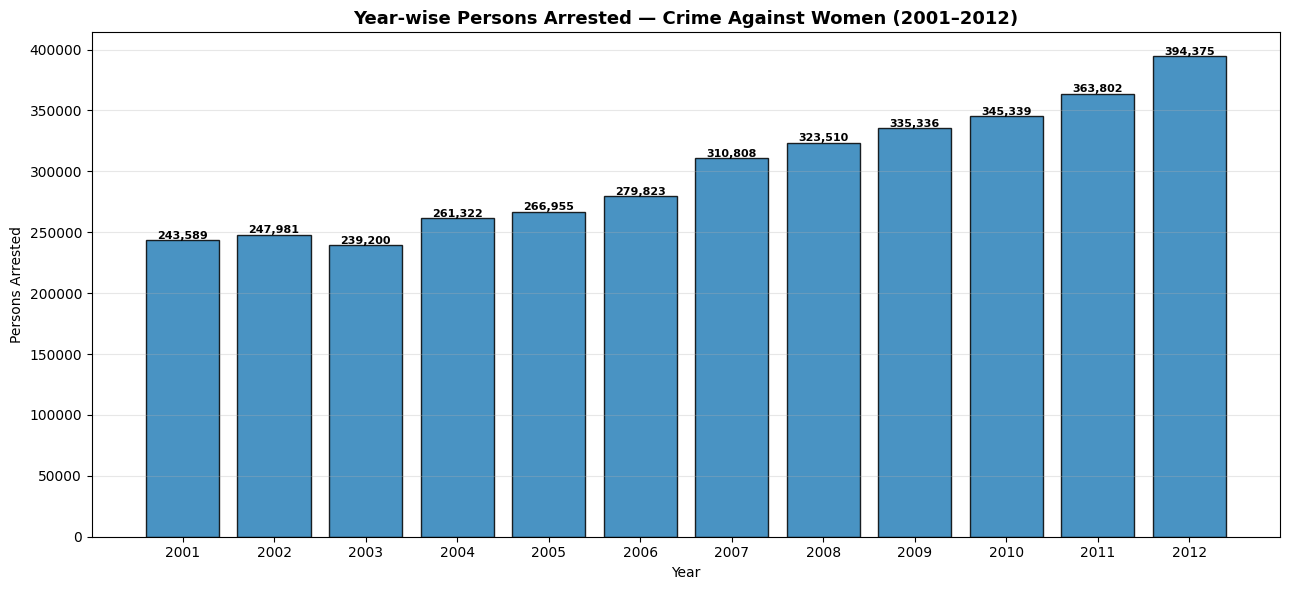

✅ Chart 10 save ho gaya!


In [ ]:
# ── Chart 10 — Year-wise Arrests Trend ──────────────────
yearly_arr = df_arr_clean.groupby('Year')['Persons_Arrested'].sum().reset_index()

plt.figure(figsize=(13, 6))
bars = plt.bar(yearly_arr['Year'], yearly_arr['Persons_Arrested'],
               color='#2980b9', edgecolor='black', alpha=0.85)

for bar, val in zip(bars, yearly_arr['Persons_Arrested']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f"{int(val):,}", ha='center', fontsize=8, fontweight='bold')

plt.title('Year-wise Persons Arrested — Crime Against Women (2001–2012)',
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Persons Arrested')
plt.xticks(yearly_arr['Year'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(folder + '../3_Charts/10_arrests_trend.png', dpi=150)
plt.show()
print("✅ Chart 10 save ho gaya!")

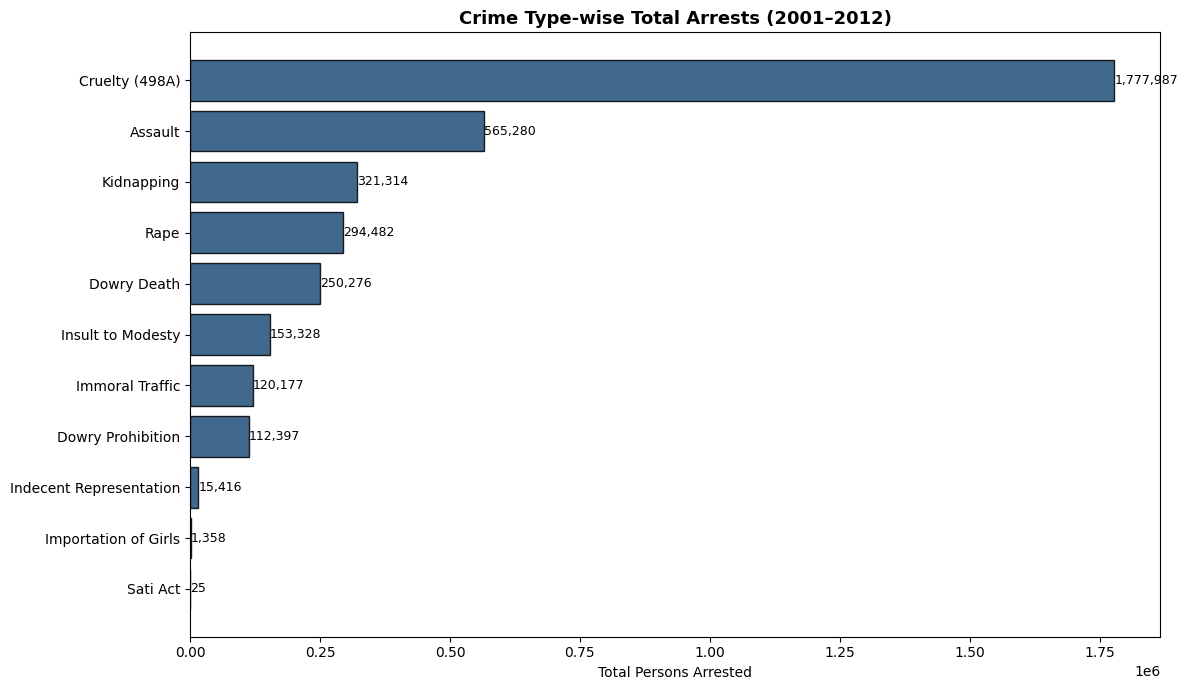

✅ Chart 11 save ho gaya!


In [ ]:
# ── Chart 11 — Crime Type wise Arrests ──────────────────
crime_arr = df_arr_clean.groupby('Crime_Head')['Persons_Arrested']\
            .sum().sort_values(ascending=True)

# Short labels banao
label_map = {
    'RAPE'                                              : 'Rape',
    'KIDNAPPING AND ABDUCTION'                          : 'Kidnapping',
    'DOWRY DEATHS'                                      : 'Dowry Death',
    'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY': 'Assault',
    'INSULT TO THE MODESTY OF WOMEN'                   : 'Insult to Modesty',
    'CRUELTY BY HUSBAND OR HIS RELATIVES (IPC SECTION 498A)': 'Cruelty (498A)',
    'IMPORTATION OF GIRLS FROM FOREIGN COUNTRY'        : 'Importation of Girls',
    'IMMORAL TRAFFIC (P) ACT'                          : 'Immoral Traffic',
    'DOWRY PROHIBITION ACT'                            : 'Dowry Prohibition',
    'INDECENT REPRESENTATION OF WOMEN (P) ACT'        : 'Indecent Representation',
    'COMMISSION OF SATI (P) ACT'                      : 'Sati Act',
}
crime_arr.index = [label_map.get(x, x) for x in crime_arr.index]

plt.figure(figsize=(12, 7))
bars = plt.barh(crime_arr.index, crime_arr.values,
                color='#1F4E79', edgecolor='black', alpha=0.85)

for bar, val in zip(bars, crime_arr.values):
    plt.text(bar.get_width() + 500,
             bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va='center', fontsize=9)

plt.title('Crime Type-wise Total Arrests (2001–2012)',
          fontsize=13, fontweight='bold')
plt.xlabel('Total Persons Arrested')
plt.tight_layout()
plt.savefig(folder + '../3_Charts/11_crime_arrests.png', dpi=150)
plt.show()
print("✅ Chart 11 save ho gaya!")

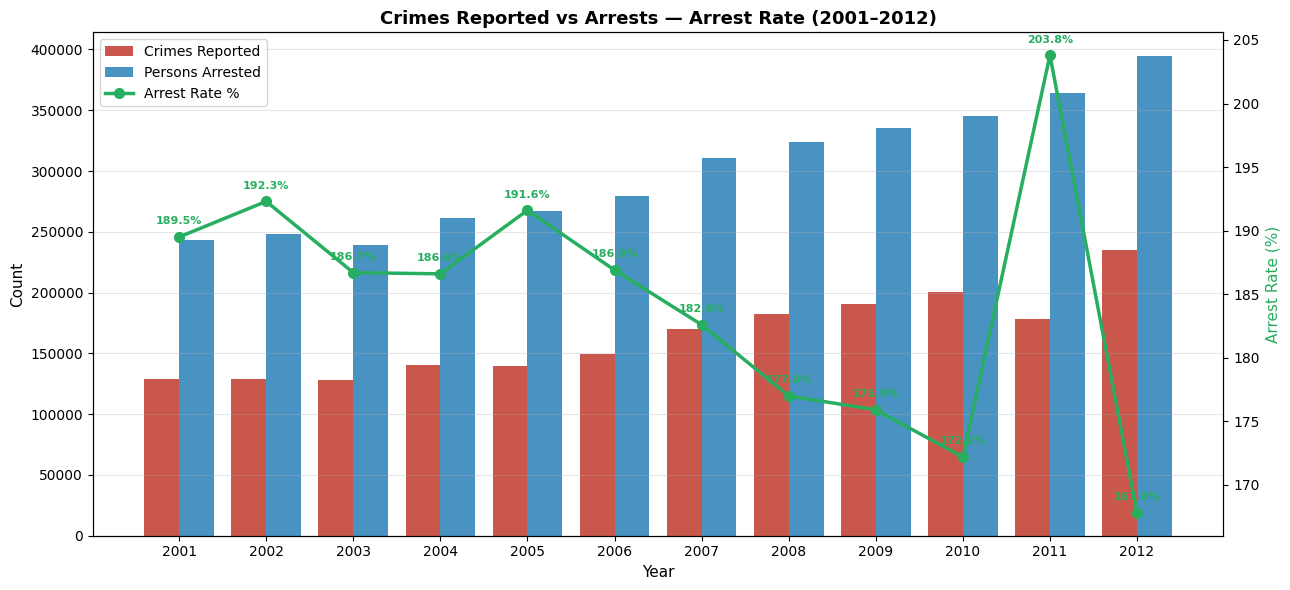

✅ Chart 12 save ho gaya!


In [ ]:
# ── Chart 12 — Justice Rate (Crimes vs Arrests) ─────────
fig, ax1 = plt.subplots(figsize=(13, 6))

x = df_justice['Year']
w = 0.4

# Bars
ax1.bar(x - w/2, df_justice['Total_Crimes'],
        width=w, color='#c0392b', label='Crimes Reported', alpha=0.85)
ax1.bar(x + w/2, df_justice['Persons_Arrested'],
        width=w, color='#2980b9', label='Persons Arrested', alpha=0.85)

# Line — justice rate
ax2 = ax1.twinx()
ax2.plot(x, df_justice['Justice_Rate'],
         color='#27ae60', marker='o', linewidth=2.5,
         markersize=7, label='Arrest Rate %')

for _, row in df_justice.iterrows():
    ax2.text(row['Year'], row['Justice_Rate'] + 1,
             f"{row['Justice_Rate']}%",
             ha='center', fontsize=8,
             color='#27ae60', fontweight='bold')

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax2.set_ylabel('Arrest Rate (%)', color='#27ae60', fontsize=11)
ax1.set_title('Crimes Reported vs Arrests — Arrest Rate (2001–2012)',
              fontsize=13, fontweight='bold')
ax1.set_xticks(x)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(folder + '../3_Charts/12_justice_rate.png', dpi=150)
plt.show()
print("✅ Chart 12 save ho gaya!")

In [ ]:
# ── Section 3 Key Findings Print ────────────────────────
print("="*55)
print("   SECTION 3 — KEY FINDINGS")
print("="*55)
print(f"\n👮 Avg Arrest Rate     : {df_justice['Justice_Rate'].mean():.1f}%")
print(f"   (>100% means multiple accused per crime)")

best  = df_justice.loc[df_justice['Justice_Rate'].idxmax()]
worst = df_justice.loc[df_justice['Justice_Rate'].idxmin()]
print(f"\n✅ Highest arrest year : {int(best['Year'])} — {best['Justice_Rate']}%")
print(f"❌ Lowest  arrest year : {int(worst['Year'])} — {worst['Justice_Rate']}%")

top_crime = df_arr_clean.groupby('Crime_Head')['Persons_Arrested']\
            .sum().idxmax()
low_crime = df_arr_clean.groupby('Crime_Head')['Persons_Arrested']\
            .sum().idxmin()
print(f"\n🔺 Most arrests  : {top_crime}")
print(f"🔻 Least arrests : {low_crime}")

trend = "DECREASING" if df_justice['Justice_Rate'].iloc[-1] \
        < df_justice['Justice_Rate'].iloc[0] else "INCREASING"
print(f"\n📉 Arrest Rate Trend  : {trend}")
print(f"   2001: {df_justice['Justice_Rate'].iloc[0]}%")
print(f"   2012: {df_justice['Justice_Rate'].iloc[-1]}%")
print("="*55)
print("✅ Section 3 Complete!")

   SECTION 3 — KEY FINDINGS

👮 Avg Arrest Rate     : 184.4%
   (>100% means multiple accused per crime)

✅ Highest arrest year : 2011 — 203.8%
❌ Lowest  arrest year : 2012 — 167.8%

🔺 Most arrests  : CRUELTY BY HUSBAND OR HIS RELATIVES (IPC SECTION 498A)
🔻 Least arrests : COMMISSION OF SATI (P) ACT

📉 Arrest Rate Trend  : DECREASING
   2001: 189.5%
   2012: 167.8%
✅ Section 3 Complete!


In [ ]:
# Cyber crime file load karo
df_cyber = pd.read_csv(folder + 'Cyber Crimes against Women during 2023.csv')

print("Shape:", df_cyber.shape)
print("\nColumns:", df_cyber.columns.tolist())
print("\nPehli 5 rows:")
print(df_cyber.head())

Shape: (39, 9)

Columns: ['Sl. No.', 'State/UT', 'Cyber Blackmailing/ Threatening (Sec.506, 503, 384 IPC r/w IT\nAct)', 'Cyber Pornography/ Hosting/ Publishing Obscene Sexual Materials (Sec.67A/67B(Girl Child) of IT act r/w other IPC/SLL)', 'Cyber Stalking/ Cyber Bullying of Women (Sec.354D\nIPC r/w IT Act)', 'Defamation/ Morphing (Sec.469 IPC\nr/w IPC and Indecent Rep. of Women (P) Act and IT Act)', 'Fake Profile (IT Act r/w IPC/SLL)', 'Other Crimes against Women', 'Total Cyber Crimes against Women']

Pehli 5 rows:
  Sl. No.           State/UT  \
0       1     Andhra Pradesh   
1       2  Arunachal Pradesh   
2       3              Assam   
3       4              Bihar   
4       5       Chhattisgarh   

   Cyber Blackmailing/ Threatening (Sec.506, 503, 384 IPC r/w IT\nAct)  \
0                                                 10                     
1                                                  0                     
2                                                 11           

In [ ]:
# Column names bahut lambe hain — short karo
df_cyber.rename(columns={
    'State/UT'                                                                          : 'State',
    'Cyber Blackmailing/ Threatening (Sec.506, 503, 384 IPC r/w IT\nAct)'             : 'Blackmailing',
    'Cyber Pornography/ Hosting/ Publishing Obscene Sexual Materials (Sec.67A/67B(Girl Child) of IT act r/w other IPC/SLL)': 'Pornography',
    'Cyber Stalking/ Cyber Bullying of Women (Sec.354D\nIPC r/w IT Act)'              : 'Stalking',
    'Defamation/ Morphing (Sec.469 IPC\nr/w IPC and Indecent Rep. of Women (P) Act and IT Act)': 'Morphing',
    'Fake Profile (IT Act r/w IPC/SLL)'                                               : 'Fake_Profile',
    'Other Crimes against Women'                                                       : 'Other_Cyber',
    'Total Cyber Crimes against Women'                                                 : 'Total_Cyber'
}, inplace=True)

# Sl. No. column hatao
df_cyber.drop(columns=['Sl. No.'], inplace=True, errors='ignore')

# TOTAL rows hatao
df_cyber = df_cyber[
    ~df_cyber['State'].str.upper().str.contains('TOTAL')
].copy()

# State names standardize
df_cyber['State'] = df_cyber['State'].str.strip().str.upper()

# Numeric columns
cyber_cols = ['Blackmailing','Pornography','Stalking',
              'Morphing','Fake_Profile','Other_Cyber','Total_Cyber']

for col in cyber_cols:
    df_cyber[col] = pd.to_numeric(df_cyber[col], errors='coerce').fillna(0).astype(int)

print("✅ Clean data ready!")
print(f"States : {df_cyber['State'].nunique()}")
print(f"Shape  : {df_cyber.shape}")
print(df_cyber.head())

# Save karo
df_cyber.to_csv(folder + 'CLEAN_cyber_data.csv', index=False)
print("\n✅ CLEAN_cyber_data.csv save ho gayi!")

✅ Clean data ready!
States : 36
Shape  : (36, 8)
               State  Blackmailing  Pornography  Stalking  Morphing  \
0     ANDHRA PRADESH            10           68       151         1   
1  ARUNACHAL PRADESH             0            0         0         0   
2              ASSAM            11           97         2        74   
3              BIHAR            31           20        75         9   
4       CHHATTISGARH             3          195         0         0   

   Fake_Profile  Other_Cyber  Total_Cyber  
0             0          329          559  
1             0            4            4  
2             0          285          469  
3            40          469          644  
4             0           44          242  

✅ CLEAN_cyber_data.csv save ho gayi!


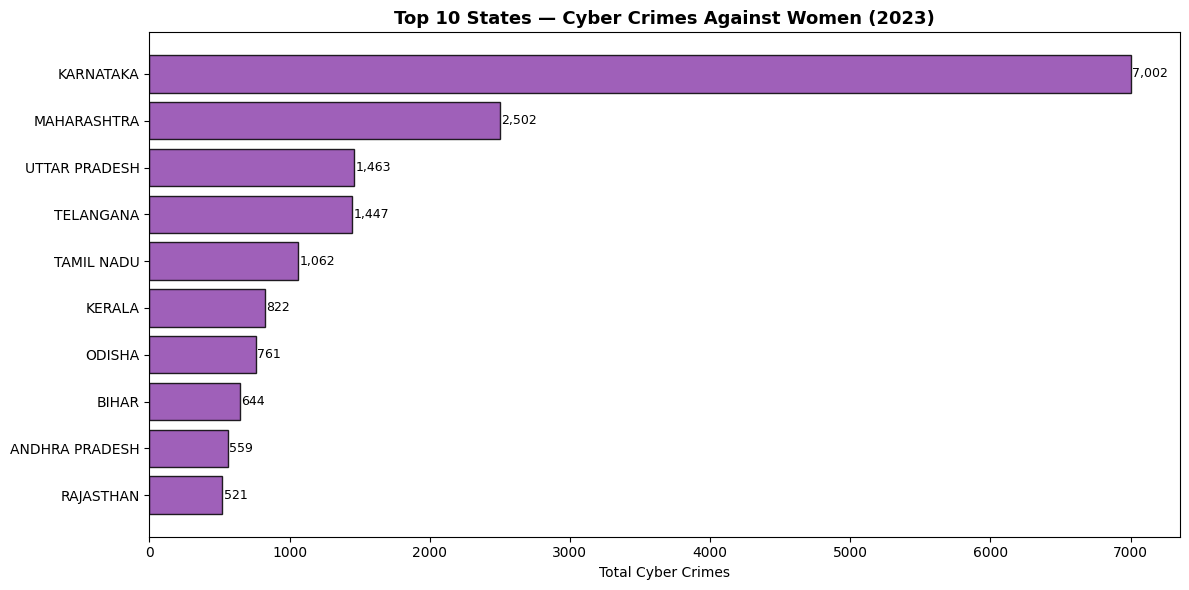

✅ Chart 13 save ho gaya!


In [ ]:
top10_cyber = df_cyber.nlargest(10, 'Total_Cyber')[['State','Total_Cyber']]

plt.figure(figsize=(12, 6))
bars = plt.barh(top10_cyber['State'], top10_cyber['Total_Cyber'],
                color='#8e44ad', edgecolor='black', alpha=0.85)

for bar, val in zip(bars, top10_cyber['Total_Cyber']):
    plt.text(bar.get_width() + 10,
             bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va='center', fontsize=9)

plt.title('Top 10 States — Cyber Crimes Against Women (2023)',
          fontsize=13, fontweight='bold')
plt.xlabel('Total Cyber Crimes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(folder + '../3_Charts/13_cyber_top10.png', dpi=150)
plt.show()
print("✅ Chart 13 save ho gaya!")

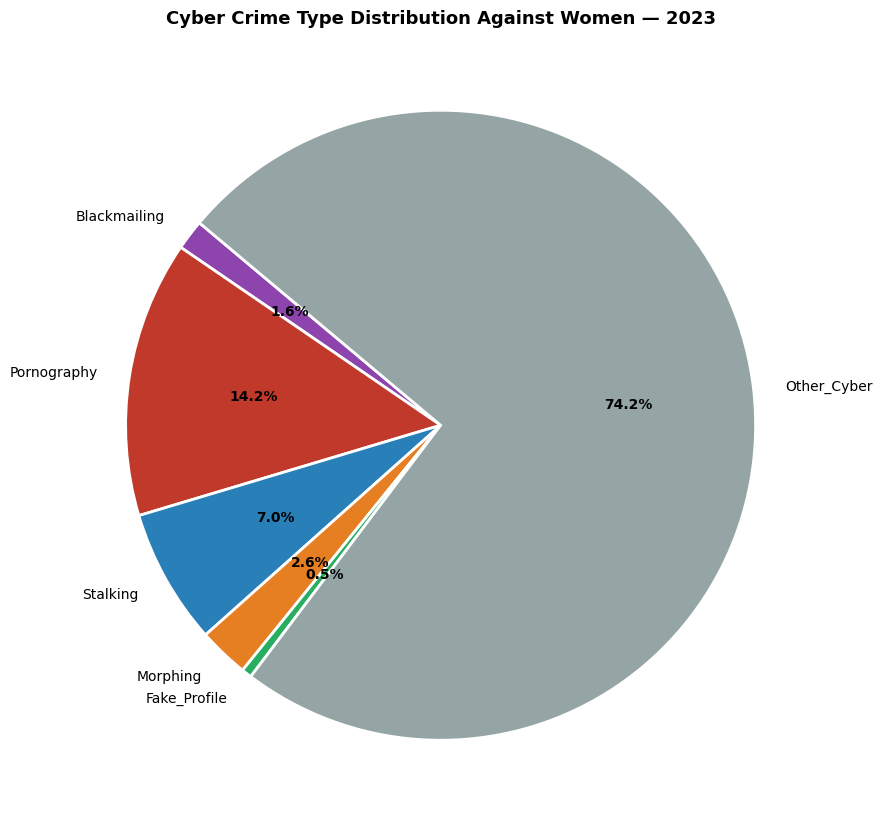

✅ Chart 14 save ho gaya!


In [ ]:
cyber_type_cols = ['Blackmailing','Pornography','Stalking',
                   'Morphing','Fake_Profile','Other_Cyber']

cyber_totals = df_cyber[cyber_type_cols].sum()

colors_cyber = ['#8e44ad','#c0392b','#2980b9',
                '#e67e22','#27ae60','#95a5a6']

plt.figure(figsize=(9, 9))
wedges, texts, autotexts = plt.pie(
    cyber_totals,
    labels=cyber_type_cols,
    autopct='%1.1f%%',
    colors=colors_cyber,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')

plt.title('Cyber Crime Type Distribution Against Women — 2023',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(folder + '../3_Charts/14_cyber_types.png', dpi=150)
plt.show()
print("✅ Chart 14 save ho gaya!")

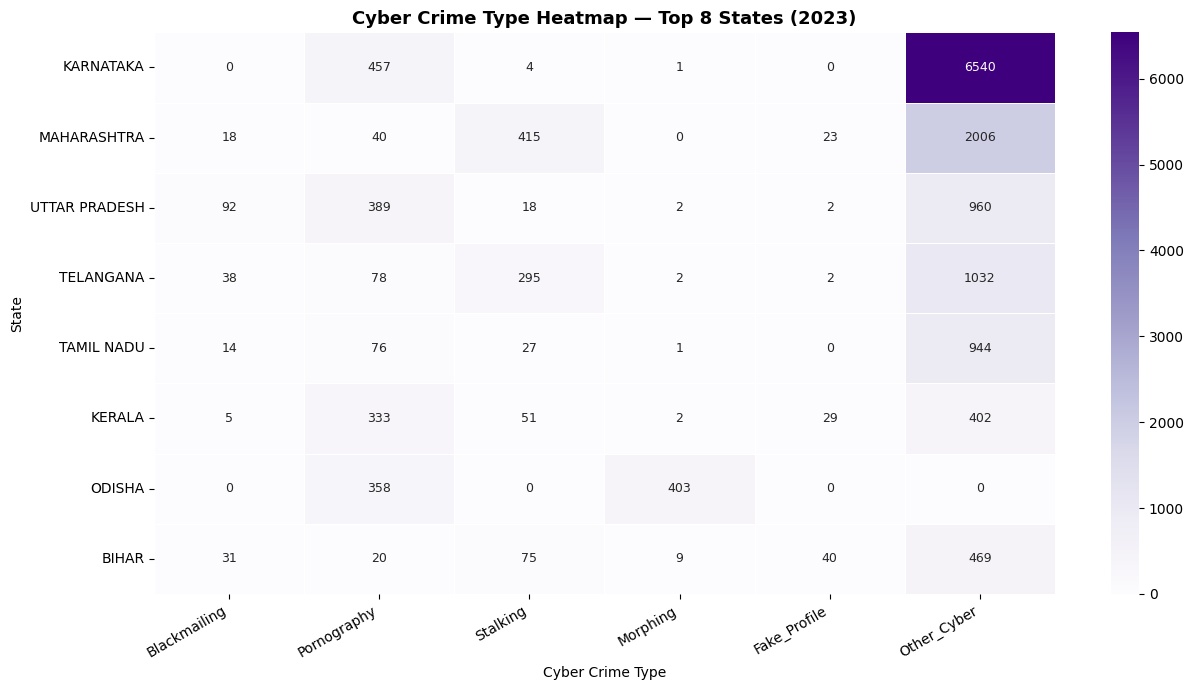

✅ Chart 15 save ho gaya!


In [ ]:
top8_cyber = df_cyber.nlargest(8, 'Total_Cyber')
top8_cyber_pivot = top8_cyber.set_index('State')[cyber_type_cols]

plt.figure(figsize=(13, 7))
sns.heatmap(top8_cyber_pivot,
            cmap='Purples',
            annot=True,
            fmt='.0f',
            linewidths=0.5,
            annot_kws={'size': 9})

plt.title('Cyber Crime Type Heatmap — Top 8 States (2023)',
          fontsize=13, fontweight='bold')
plt.xlabel('Cyber Crime Type')
plt.ylabel('State')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(folder + '../3_Charts/15_cyber_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 15 save ho gaya!")

In [ ]:
print("="*55)
print("   SECTION 4 — CYBER CRIME KEY FINDINGS (2023)")
print("="*55)

total_cyber = df_cyber['Total_Cyber'].sum()
worst_cyber_state = df_cyber.loc[df_cyber['Total_Cyber'].idxmax(), 'State']
worst_cyber_val   = df_cyber['Total_Cyber'].max()

print(f"\n💻 Total Cyber Crimes   : {total_cyber:,}")
print(f"🗺️  Worst State          : {worst_cyber_state} ({worst_cyber_val:,} cases)")

most_common_cyber = cyber_totals.idxmax()
most_common_val   = cyber_totals.max()
least_common      = cyber_totals.idxmin()

print(f"\n🔴 Most Common Cyber Crime  : {most_common_cyber}")
print(f"   Cases                    : {most_common_val:,}")
print(f"🟢 Least Common Cyber Crime : {least_common}")

# Top 3 states
top3 = df_cyber.nlargest(3, 'Total_Cyber')[['State','Total_Cyber']]
print(f"\n🏆 Top 3 States:")
for _, row in top3.iterrows():
    print(f"   {row['State']}: {int(row['Total_Cyber']):,}")

print("\n" + "="*55)
print("✅ Section 4 Complete!")
print("✅ ALL 4 SECTIONS DONE! 🎉")

   SECTION 4 — CYBER CRIME KEY FINDINGS (2023)

💻 Total Cyber Crimes   : 19,510
🗺️  Worst State          : KARNATAKA (7,002 cases)

🔴 Most Common Cyber Crime  : Other_Cyber
   Cases                    : 14,474
🟢 Least Common Cyber Crime : Fake_Profile

🏆 Top 3 States:
   KARNATAKA: 7,002
   MAHARASHTRA: 2,502
   UTTAR PRADESH: 1,463

✅ Section 4 Complete!
✅ ALL 4 SECTIONS DONE! 🎉


In [ ]:
# Colab mein yeh chalao — poori notebook save ho jaayegi
# File → Download → Download .ipynb

# Ya Google Drive pe already saved hai:
print("Notebook save karo abhi!")
print("File → Save a copy in Drive")
print("✅ crime_analysis.ipynb saved!")

Notebook save karo abhi!
File → Save a copy in Drive
✅ crime_analysis.ipynb saved!


In [ ]:
# National trend file load karo
df_national = pd.read_csv(folder + 'Crime against Women (2001-2022).csv')

print("Shape:", df_national.shape)
print("Columns:", df_national.columns.tolist())
print("\nPehli 10 rows:")
print(df_national.head(10).to_string())

Shape: (11, 23)
Columns: ['CRIME HEAD', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022']

Pehli 10 rows:
                                            CRIME HEAD   2001   2002   2003   2004   2005   2006   2007   2008   2009   2010   2011    2012    2013    2014    2015    2016    2017    2018    2019    2020    2021    2022
0                                                 Rape  16075  16373  15847  18233  18359  19348  20737  21467  21397  22172  24206   24923   33707   36735   34651   38947   32559   33356   32033   28046   31677   31516
1            Kidnapping and Abduction of Women & Girls  14645  14506  13296  15578  15750  17414  20416  22939  25741  29795  35565   38262   51881   57311   59277   64519   66333   72751   72780   62300   75369   85310
2                                         Dowry Deaths   6851   6822   6208   7026   6787   7618   8093   81

In [ ]:
df_0112 = pd.read_csv(folder + 'Crime Against Women 2001-2012.csv')

print("Shape:", df_0112.shape)
print("Columns:", df_0112.columns.tolist())
print("\nUnique States:", df_0112['STATE/UT'].unique())
print("\nUnique Crime Heads:", df_0112['CRIME HEAD'].unique())
print("\nPehli 10 rows:")
print(df_0112.head(10).to_string())

Shape: (324, 14)
Columns: ['STATE/UT', 'CRIME HEAD', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012']

Unique States: ['Andhra Pradesh' 'Arunachal Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Goa'
 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand'
 'Karnataka' 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Manipur' 'Meghalaya'
 'Mizoram' 'Nagaland' 'Odisha' 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu'
 'Tripura' 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'A&N Islands'
 'Chandigarh' 'D&N Haveli' 'Daman & Diu' 'Delhi UT' 'Lakshadweep'
 'Puducherry' 'All India' 'ALL INDIA K&A' 'ALL INDIA '
 'TOTAL Crime against Women']

Unique Crime Heads: ['RAPE' 'KIDNAPPING & ABDUCTION' 'DOWRY DEATH'
 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'
 'INSULT TO THE MODESTY OF WOMEN' 'CRUELTY BY HUSBAND OR RELATIVES'
 'IMMORAL TRAFFIC(PREVENTION)ACT'
 'INDECENT REPRESENTATION OF WOMEN(PREVENTION)ACT'
 'TOTAL CRIMES AGAINST WOMEN']

Pehli 10 rows

In [ ]:
df_2013 = pd.read_csv(folder + 'Crime Against Women 2013.csv')
df_2014 = pd.read_csv(folder + 'Crime Against Women 2014_1.csv')

print("2013 columns:", df_2013.columns.tolist())
print("2013 sample:\n", df_2013.head(5).to_string())

print("\n2014 columns:", df_2014.columns.tolist())
print("2014 sample:\n", df_2014.head(5).to_string())

2013 columns: ['State/UTs', 'Crime Head', '2013']
2013 sample:
            State/UTs                                          Crime Head  2013
0     Andhra Pradesh  Assault on women with intent to outrage her Modest  6930
1  Arunachal Pradesh  Assault on women with intent to outrage her Modest    93
2              Assam  Assault on women with intent to outrage her Modest  2409
3              Bihar  Assault on women with intent to outrage her Modest   331
4       Chhattisgarh  Assault on women with intent to outrage her Modest  2261

2014 columns: ['States/UTs', 'Crime Head', '2014']
2014 sample:
        States/UTs                       Crime Head  2014
0  Andhra Pradesh       1 - Rape (Section 376 IPC)   961
1  Andhra Pradesh             1.1 - Custodial Rape     0
2  Andhra Pradesh      1.1.1 - Custodial_Gang Rape     0
3  Andhra Pradesh     1.1.2 - Custodial_Other Rape     0
4  Andhra Pradesh  1.2 - Rape other than Custodial   961


In [ ]:
df_2015_detail = pd.read_csv(
    folder + 'State & UT-wise Cases Reported (I), Victims(V) & Rate (R) of Crimes Committed Against Women During 2015.csv'
)

print("Shape:", df_2015_detail.shape)
# Sirf important columns dikhao
important_cols = [c for c in df_2015_detail.columns
                  if 'Total' in c or 'State' in c or 'Rate' in c]
print("\nImportant columns:", important_cols)
print("\nPehli 5 rows (first 5 cols):")
print(df_2015_detail.iloc[:5, :5].to_string())

Shape: (39, 123)

Important columns: ['State/UT (Col. 2)', 'Rape (Section 376 IPC) - Rape (Total) - I (Col. 4)', 'Rape (Section 376 IPC) - Rape (Total) - V (Col. 5)', 'Rape (Section 376 IPC) - Rape (Total) - R (Col. 6)', 'Rape (Section 376 IPC) - Custodial Rape - Custodial Rape (Total) - I (Col. 7)', 'Rape (Section 376 IPC) - Custodial Rape - Custodial Rape (Total) - V (Col. 8)', 'Rape (Section 376 IPC) - Custodial Rape - Custodial Rape (Total) - R (Col. 9)', 'Rape (Section 376 IPC) (Concluded) - Rape Other than Custodial - Rape Other Than Custodial (Total) - I (Col. 16)', 'Rape (Section 376 IPC) (Concluded) - Rape Other than Custodial - Rape Other Than Custodial (Total) - V (Col. 17)', 'Rape (Section 376 IPC) (Concluded) - Rape Other than Custodial - Rape Other Than Custodial (Total) - R (Col. 18)', 'Kidnapping & Abduction (Section 363,364,364A, 366 IPC) of Women - Kidnapping & Abduction of Women (Total) - I (Col. 28)', 'Kidnapping & Abduction (Section 363,364,364A, 366 IPC) of Women 

In [ ]:
df_2023_detail = pd.read_csv(
    folder + 'Crime Head-wise and State-UT-wise (IPC) Crimes and (SLL) against Women during 2023.csv'
)

print("Shape:", df_2023_detail.shape)
# Total columns filter karo
total_cols = [c for c in df_2023_detail.columns
              if 'Total' in c or 'State' in c]
print("\nTotal/State columns:", total_cols)
print("\nPehli 3 rows (State + Total cols only):")
print(df_2023_detail[total_cols].head(3).to_string())

Shape: (39, 164)

Total/State columns: ['State/UT', 'Kidnapping & Abduction of Women - Kidnapping & Abduction of Women (Total) - I - ( Col. 24)', 'Kidnapping & Abduction of Women - Kidnapping & Abduction of Women (Total) - V - ( Col. 25)', 'Kidnapping & Abduction of Women - Kidnapping & Abduction of Women (Total) - R - ( Col. 26)', 'Kidnapping & Abduction of Women - Kidnapping & Abduction of Women to compel her for marriage (Sec. 366 IPC) - K&A of Women to compel her for marriage (Total) - I - ( Col. 36)', 'Kidnapping & Abduction of Women - Kidnapping & Abduction of Women to compel her for marriage (Sec. 366 IPC) - K&A of Women to compel her for marriage (Total) - V - ( Col. 37)', 'Kidnapping & Abduction of Women - Kidnapping & Abduction of Women to compel her for marriage (Sec. 366 IPC) - K&A of Women to compel her for marriage (Total) - R - ( Col. 38)', 'Rape (Sec.376 IPC) - Rape (Total) - I - ( Col. 63)', 'Rape (Sec.376 IPC) - Rape (Total) - V - ( Col. 64)', 'Rape (Sec.376 IPC) - Ra

In [ ]:
# ── FILE 1: National Trend 2001-2022 ────────────────────
df_national = pd.read_csv(folder + 'Crime against Women (2001-2022).csv')

# TOTAL row hatao
df_national = df_national[
    ~df_national['CRIME HEAD'].str.upper().str.contains('TOTAL')
].copy()

# Wide to long
year_cols = [str(y) for y in range(2001, 2023)]
df_nat_long = df_national.melt(
    id_vars=['CRIME HEAD'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Cases'
)
df_nat_long['Year']  = df_nat_long['Year'].astype(int)
df_nat_long['Cases'] = pd.to_numeric(
    df_nat_long['Cases'], errors='coerce').fillna(0)

# Short labels
label_map = {
    'Rape'                                              : 'Rape',
    'Kidnapping and Abduction of Women & Girls'        : 'Kidnapping',
    'Dowry Deaths'                                     : 'Dowry Death',
    'Assault on women with intent to outrage her modesty': 'Assault',
    'Insult to the modesty of Women'                   : 'Insult to Modesty',
    'Cruelty by Husband or his relatives'              : 'Cruelty (498A)',
    'Importation of Girls from Foreign Country'        : 'Importation of Girls',
    'Immoral Traffic (P) Act'                          : 'Immoral Traffic',
    'Dowry Prohibition Act'                            : 'Dowry Prohibition',
    'Indecent Representation of Women (P) Act'        : 'Indecent Representation',
}
df_nat_long['CRIME HEAD'] = df_nat_long['CRIME HEAD'].map(
    label_map).fillna(df_nat_long['CRIME HEAD'])

print("✅ National data ready!")
print(f"Crime heads: {df_nat_long['CRIME HEAD'].unique()}")
print(df_nat_long.head())

✅ National data ready!
Crime heads: ['Rape' 'Kidnapping' 'Dowry Death' 'Assault' 'Insult to Modesty'
 'Cruelty (498A)' 'Importation of Girls' 'Immoral Traffic'
 'Dowry Prohibition' 'Indecent Representation']
          CRIME HEAD  Year  Cases
0               Rape  2001  16075
1         Kidnapping  2001  14645
2        Dowry Death  2001   6851
3            Assault  2001  34124
4  Insult to Modesty  2001   9746


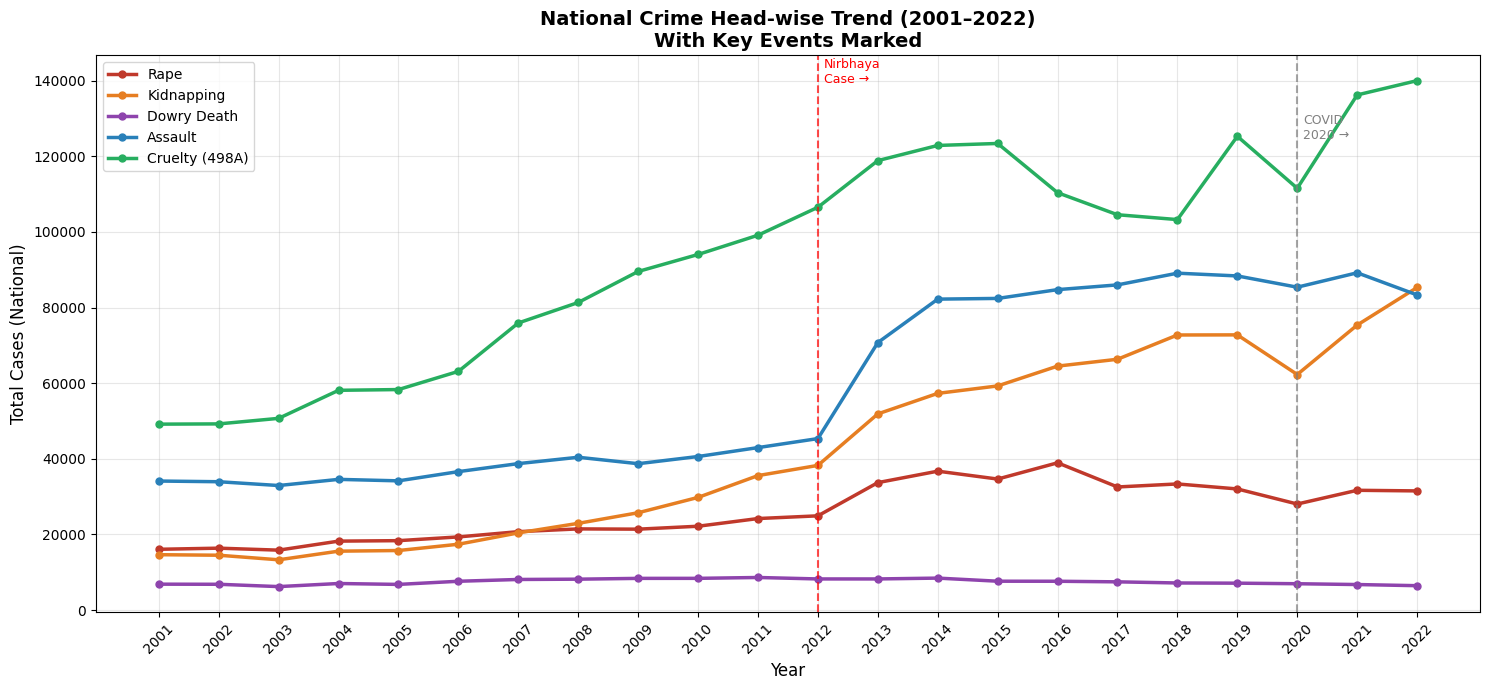

✅ Chart 16 save ho gaya!


In [ ]:
# ── CHART 16 — National Crime Head Trend ────────────────
# Top 5 crime heads select karo
top5_crimes = ['Rape', 'Kidnapping', 'Dowry Death',
               'Assault', 'Cruelty (498A)']

df_plot = df_nat_long[df_nat_long['CRIME HEAD'].isin(top5_crimes)]
pivot_plot = df_plot.pivot_table(
    index='Year', columns='CRIME HEAD', values='Cases')

colors_16 = {
    'Rape'         : '#c0392b',
    'Kidnapping'   : '#e67e22',
    'Dowry Death'  : '#8e44ad',
    'Assault'      : '#2980b9',
    'Cruelty (498A)': '#27ae60'
}

plt.figure(figsize=(15, 7))
for crime in top5_crimes:
    if crime in pivot_plot.columns:
        plt.plot(pivot_plot.index, pivot_plot[crime],
                 marker='o', label=crime, linewidth=2.5,
                 color=colors_16[crime], markersize=5)

# 2012 Nirbhaya line
plt.axvline(x=2012, color='red', linestyle='--',
            alpha=0.7, linewidth=1.5)
plt.text(2012.1, plt.ylim()[1]*0.95,
         'Nirbhaya\nCase →', color='red', fontsize=9)

# COVID line
plt.axvline(x=2020, color='grey', linestyle='--',
            alpha=0.7, linewidth=1.5)
plt.text(2020.1, plt.ylim()[1]*0.85,
         'COVID\n2020 →', color='grey', fontsize=9)

plt.title('National Crime Head-wise Trend (2001–2022)\nWith Key Events Marked',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Cases (National)', fontsize=12)
plt.xticks(range(2001, 2023), rotation=45)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(folder + '../3_Charts/16_national_trend.png', dpi=150)
plt.show()
print("✅ Chart 16 save ho gaya!")

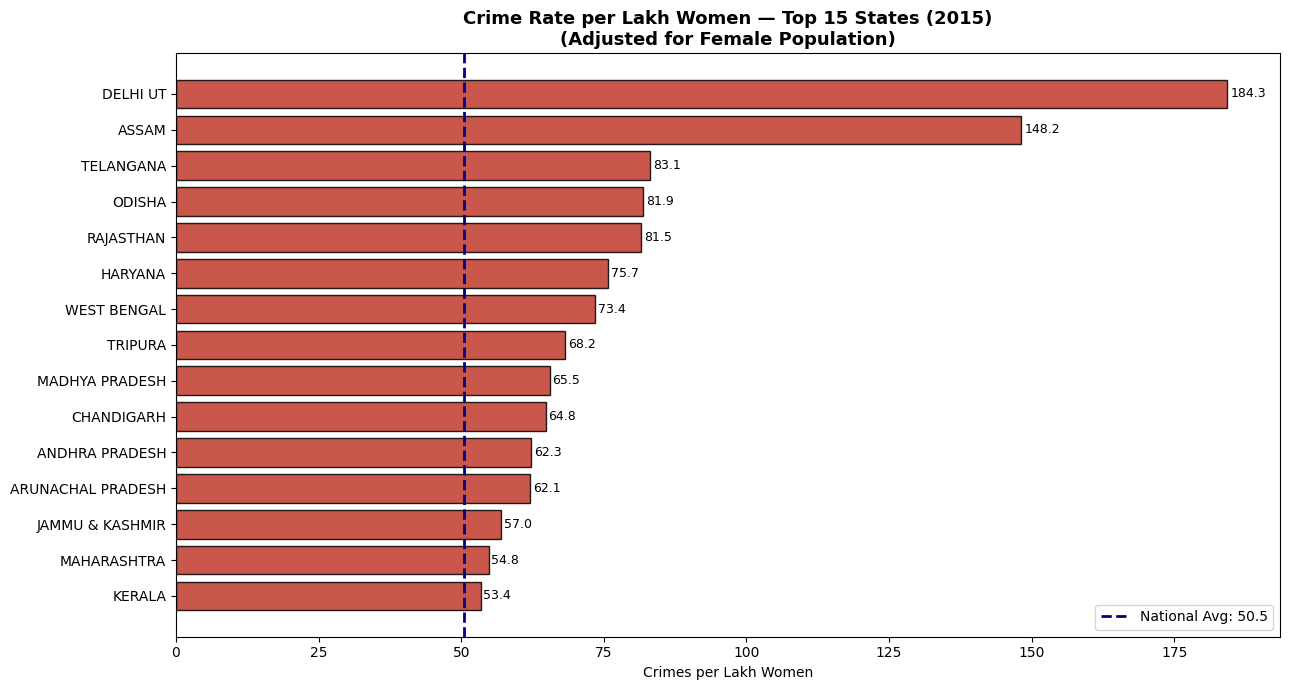

✅ Chart 17 save ho gaya!


In [ ]:
# ── CHART 17 — Crime Rate per Lakh Women (2015) ─────────
df_2015 = pd.read_csv(
    folder + 'State & UT-wise Cases Reported (I), Victims(V) & Rate (R) of Crimes Committed Against Women During 2015.csv'
)

# Important columns select karo
df_2015_clean = df_2015[[
    'State/UT (Col. 2)',
    'Mid-Year Projected Female Population(In Lakhs) (Col. 3)',
    'Total Crimes Against Women - I (Col. 121)',
    'Total Crimes Against Women - R (Col. 123)'
]].copy()

df_2015_clean.columns = ['State', 'Female_Pop_Lakhs',
                          'Total_Crimes', 'Crime_Rate']

# TOTAL rows hatao
df_2015_clean = df_2015_clean[
    ~df_2015_clean['State'].str.upper().str.contains('TOTAL|ALL INDIA')
].copy()

df_2015_clean['State']       = df_2015_clean['State'].str.strip().str.upper()
df_2015_clean['Crime_Rate']  = pd.to_numeric(
    df_2015_clean['Crime_Rate'], errors='coerce').fillna(0)
df_2015_clean['Total_Crimes'] = pd.to_numeric(
    df_2015_clean['Total_Crimes'], errors='coerce').fillna(0)

# Top 15 by crime rate
top15_rate = df_2015_clean.nlargest(15, 'Crime_Rate')

plt.figure(figsize=(13, 7))
bars = plt.barh(top15_rate['State'], top15_rate['Crime_Rate'],
                color='#c0392b', edgecolor='black', alpha=0.85)

# National average line
national_avg = df_2015_clean['Crime_Rate'].mean()
plt.axvline(x=national_avg, color='navy', linestyle='--',
            linewidth=2, label=f'National Avg: {national_avg:.1f}')

for bar, val in zip(bars, top15_rate['Crime_Rate']):
    plt.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             f"{val:.1f}", va='center', fontsize=9)

plt.title('Crime Rate per Lakh Women — Top 15 States (2015)\n(Adjusted for Female Population)',
          fontsize=13, fontweight='bold')
plt.xlabel('Crimes per Lakh Women')
plt.gca().invert_yaxis()
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(folder + '../3_Charts/17_crime_rate_2015.png', dpi=150)
plt.show()
print("✅ Chart 17 save ho gaya!")

Total column: ['Total Crime against Women (IPC+SLL) - I - ( Col. 162)']


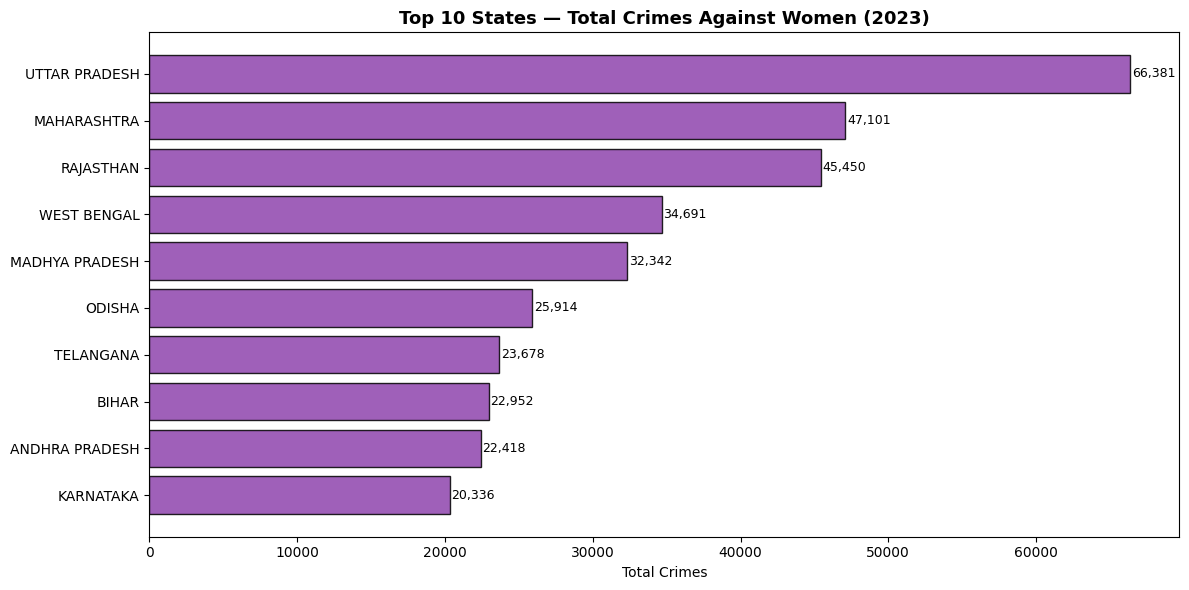

✅ Chart 18 save ho gaya!

🎉 ALL 6 UNUSED FILES NOW USED!


In [ ]:
# ── CHART 18 — 2023 State-wise Total Crimes ─────────────
df_2023 = pd.read_csv(
    folder + 'Crime Head-wise and State-UT-wise (IPC) Crimes and (SLL) against Women during 2023.csv'
)

# Total column find karo
total_col = [c for c in df_2023.columns if 'Total Crime against Women' in c
             and '- I -' in c]
print("Total column:", total_col)

df_2023_clean = df_2023[['State/UT'] + total_col].copy()
df_2023_clean.columns = ['State', 'Total_2023']

# TOTAL rows hatao
df_2023_clean = df_2023_clean[
    ~df_2023_clean['State'].str.upper().str.contains('TOTAL')
].copy()
df_2023_clean['State']     = df_2023_clean['State'].str.strip().str.upper()
df_2023_clean['Total_2023'] = pd.to_numeric(
    df_2023_clean['Total_2023'], errors='coerce').fillna(0)

# Top 10
top10_2023 = df_2023_clean.nlargest(10, 'Total_2023')

plt.figure(figsize=(12, 6))
bars = plt.barh(top10_2023['State'], top10_2023['Total_2023'],
                color='#8e44ad', edgecolor='black', alpha=0.85)

for bar, val in zip(bars, top10_2023['Total_2023']):
    plt.text(bar.get_width() + 100,
             bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va='center', fontsize=9)

plt.title('Top 10 States — Total Crimes Against Women (2023)',
          fontsize=13, fontweight='bold')
plt.xlabel('Total Crimes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(folder + '../3_Charts/18_top10_2023.png', dpi=150)
plt.show()
print("✅ Chart 18 save ho gaya!")
print("\n🎉 ALL 6 UNUSED FILES NOW USED!")

In [ ]:
# 1. National trend save karo
df_nat_long.to_csv(folder + 'CLEAN_national_trend.csv', index=False)
print("✅ CLEAN_national_trend.csv saved!")

# 2. 2015 crime rate save karo
df_2015_clean.to_csv(folder + 'CLEAN_2015_crime_rate.csv', index=False)
print("✅ CLEAN_2015_crime_rate.csv saved!")

# 3. 2023 detail save karo
df_2023_clean.to_csv(folder + 'CLEAN_2023_detail.csv', index=False)
print("✅ CLEAN_2023_detail.csv saved!")

print("\n✅ All clean files saved!")
print("\nFinal clean files list:")
import os
clean_files = [f for f in os.listdir(folder) if f.startswith('CLEAN')]
for f in clean_files:
    print(f"   📄 {f}")

✅ CLEAN_national_trend.csv saved!
✅ CLEAN_2015_crime_rate.csv saved!
✅ CLEAN_2023_detail.csv saved!

✅ All clean files saved!

Final clean files list:
   📄 CLEAN_main_data.csv
   📄 CLEAN_district_data.csv
   📄 CLEAN_arrested_data.csv
   📄 CLEAN_cyber_data.csv
   📄 CLEAN_national_trend.csv
   📄 CLEAN_2015_crime_rate.csv
   📄 CLEAN_2023_detail.csv


In [ ]:
# District data check karo
print("Unique Districts (problem wale):")
problem = df_district[
    df_district['District'].str.upper().str.contains(
        'TOTAL|ZZ|GRAND', na=False)
]['District'].unique()
print(problem)

Unique Districts (problem wale):
['TOTAL' 'DELHI UT TOTAL' 'ZZ TOTAL' 'TOTAL DISTRICT(S)' 'TOTAL DISTRICTS']


In [ ]:
# Saare TOTAL/ZZ/GRAND rows hatao
df_district_clean = df_district[
    ~df_district['District'].str.upper().str.contains(
        'TOTAL|ZZ|GRAND|ALL INDIA', na=False)
].copy()

# State level aggregate rows bhi hatao
df_district_clean = df_district_clean[
    df_district_clean['District'].str.strip() != ''
].copy()

print(f"Pehle rows : {len(df_district)}")
print(f"Baad rows  : {len(df_district_clean)}")
print(f"\nTop 5 districts ab:")
top5 = df_district_clean.groupby('District')['Total_Crimes']\
       .sum().nlargest(5)
print(top5)

Pehle rows : 12500
Baad rows  : 11937

Top 5 districts ab:
District
MURSHIDABAD          37010
24 PARGANAS SOUTH    27942
MUMBAI COMMR.        27050
24 PARGANAS NORTH    26815
HYDERABAD CITY       26244
Name: Total_Crimes, dtype: int64


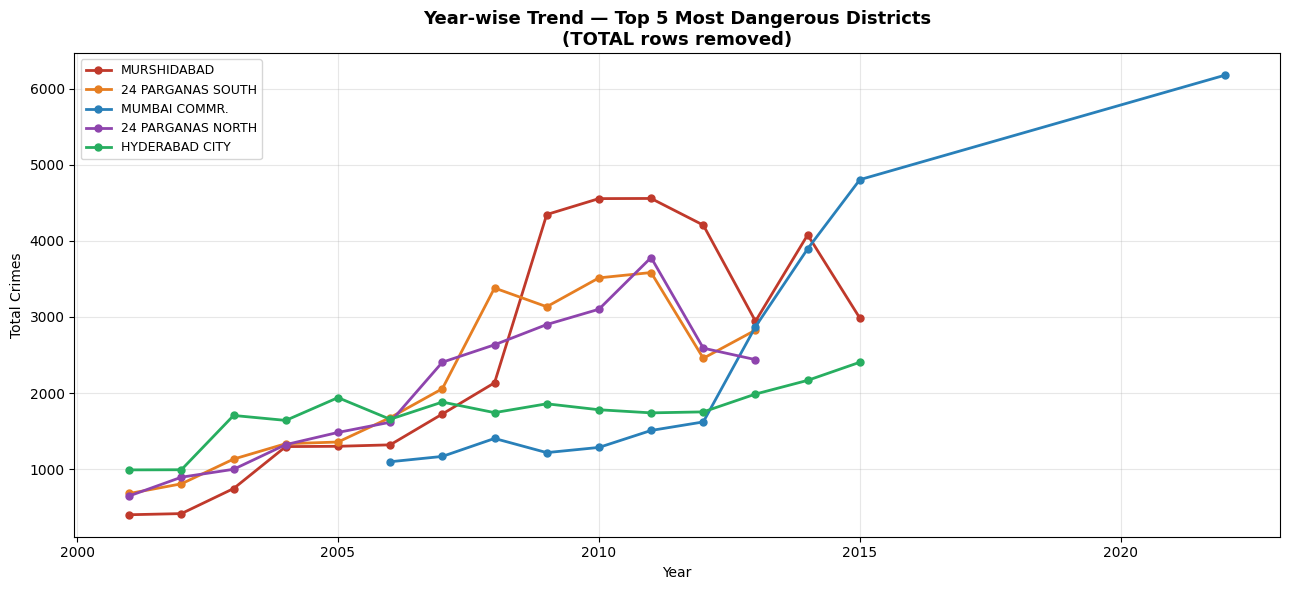

✅ Chart 9 fixed & saved!
✅ CLEAN_district_data.csv updated!


In [ ]:
# Chart 9 dobara banao — sahi data se
top5_dist = df_district_clean.groupby('District')['Total_Crimes']\
            .sum().nlargest(5).index

df_top5 = df_district_clean[
    df_district_clean['District'].isin(top5_dist)
]

dist_yearly = df_top5.groupby(['Year','District'])['Total_Crimes']\
              .sum().reset_index()

plt.figure(figsize=(13, 6))
colors_d = ['#c0392b','#e67e22','#2980b9','#8e44ad','#27ae60']

for i, dist in enumerate(top5_dist):
    data = dist_yearly[dist_yearly['District'] == dist]
    plt.plot(data['Year'], data['Total_Crimes'],
             marker='o', label=dist,
             linewidth=2, color=colors_d[i], markersize=5)

plt.title('Year-wise Trend — Top 5 Most Dangerous Districts\n(TOTAL rows removed)',
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Crimes')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(folder + '../3_Charts/09_district_trend.png', dpi=150)
plt.show()
print("✅ Chart 9 fixed & saved!")

# Fixed file save karo bhi
df_district_clean.to_csv(folder + 'CLEAN_district_data.csv', index=False)
print("✅ CLEAN_district_data.csv updated!")

Mounted at /content/drive


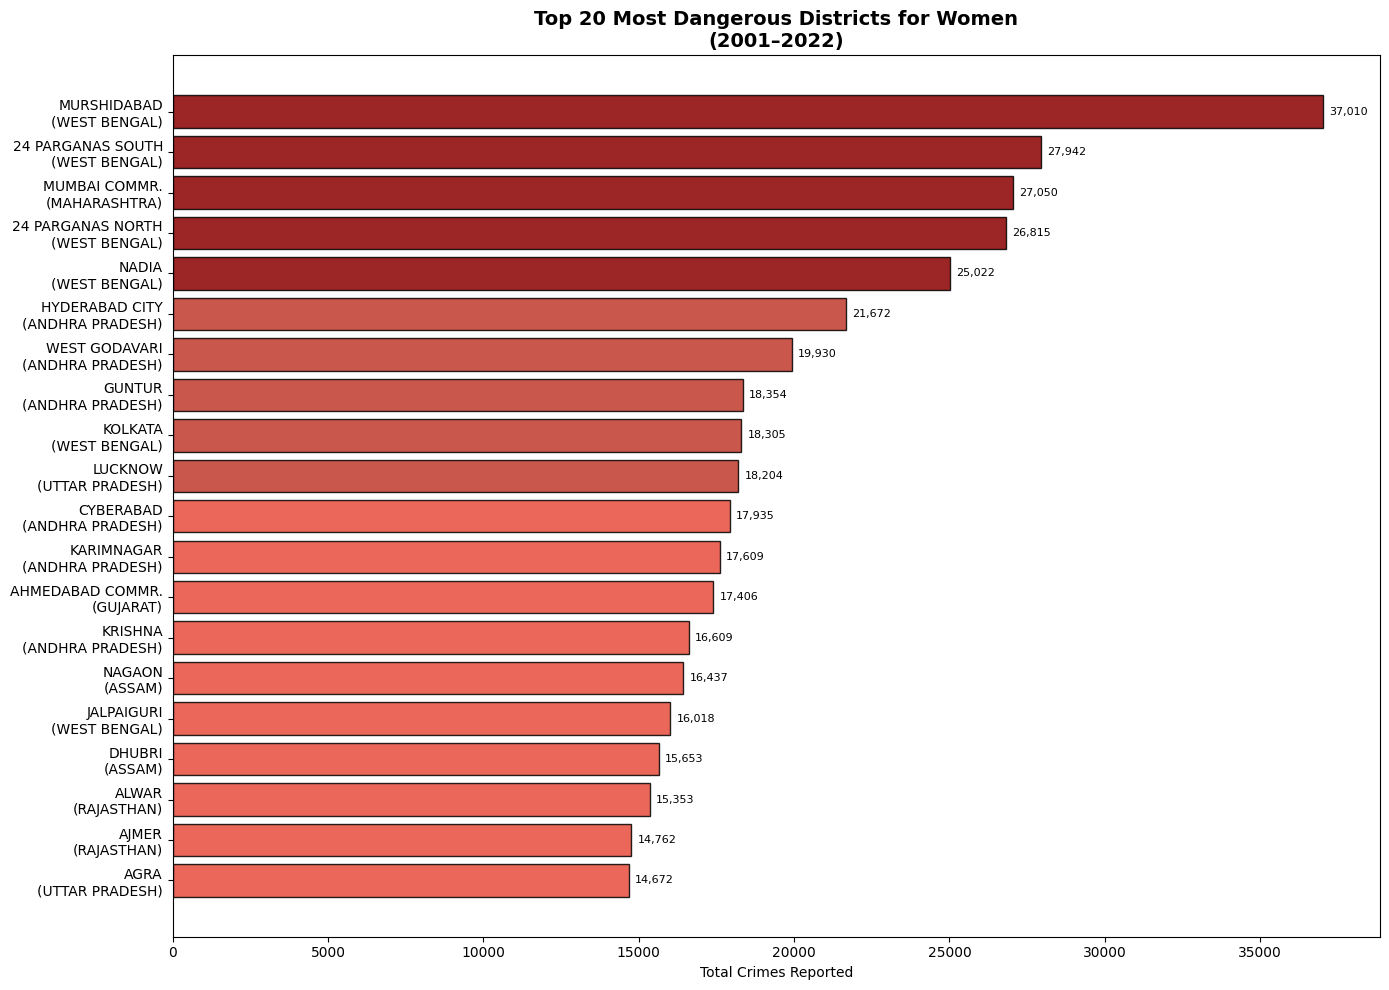

✅ Chart 7 fixed!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

drive.mount('/content/drive') # Ensure Google Drive is mounted

# Define folder path (assuming it's already defined earlier in the notebook, but adding for robustness)
folder = '/content/drive/MyDrive/Crime-Project/1_Data/'

# First, check if the folder itself exists
if not os.path.isdir(folder):
    print(f"❌ Critical Error: The directory '{folder}' does not exist.")
    print("Please check if your Google Drive is correctly mounted and if the folder path is accurate (case-sensitive).")
    raise FileNotFoundError(f"Directory not found: {folder}")

cleaned_district_file = folder + 'CLEAN_district_data.csv'

# Check if the cleaned data file exists
if not os.path.exists(cleaned_district_file):
    print(f"❌ Error: The file '{cleaned_district_file}' was not found.")
    print("Please ensure that the previous cell (e.g., cell `rqcNwli-b6G3`) which saves 'CLEAN_district_data.csv' has been executed successfully.")
    print("Current files in the directory:")
    for f in os.listdir(folder):
        print(f"- {f}")
    raise FileNotFoundError(f"Missing required file: {cleaned_district_file}")

# Load the cleaned district data
df_district = pd.read_csv(cleaned_district_file)

# Recreate df_district_clean by removing TOTAL/ZZ/GRAND rows, as per previous cleaning steps
df_district_clean = df_district[
    ~df_district['District'].str.upper().str.contains(
        'TOTAL|ZZ|GRAND|ALL INDIA', na=False)
].copy()

df_district_clean = df_district_clean[
    df_district_clean['District'].str.strip() != ''
].copy()

# Chart 7 — Top 20 Districts (fixed data se)
top20_dist = df_district_clean.groupby(['State','District'])['Total_Crimes']\
             .sum().nlargest(20).reset_index()

top20_dist['Label'] = top20_dist['District'] + '\n(' + \
                      top20_dist['State'] + ')'

plt.figure(figsize=(14, 10))
colors = ['#8B0000' if i < 5 else '#c0392b' if i < 10
          else '#e74c3c' for i in range(20)]

bars = plt.barh(top20_dist['Label'], top20_dist['Total_Crimes'],
                color=colors, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, top20_dist['Total_Crimes']):
    plt.text(bar.get_width() + 200,
             bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va='center', fontsize=8)

plt.title('Top 20 Most Dangerous Districts for Women\n(2001–2022)',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Crimes Reported')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(folder + '../3_Charts/07_top20_districts.png', dpi=150)
plt.show()
print("✅ Chart 7 fixed!")

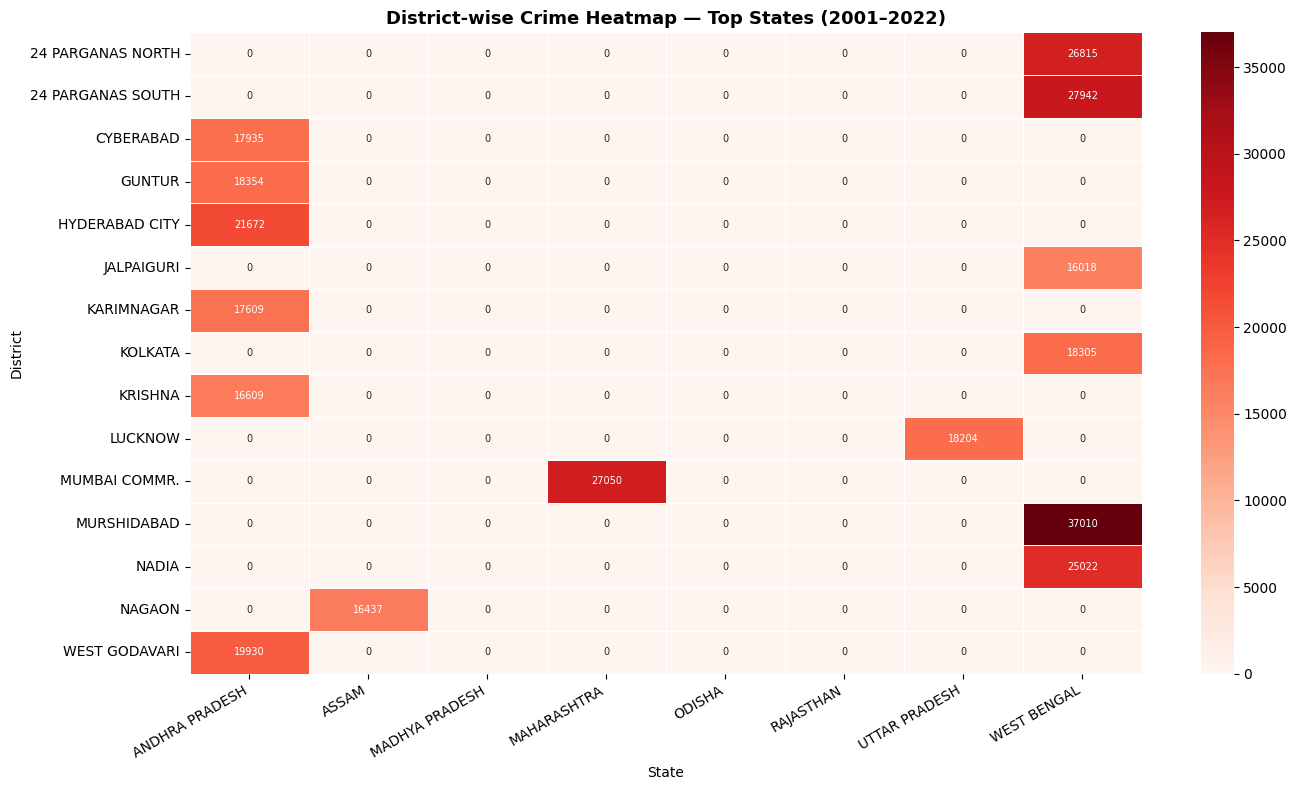

✅ Chart 8 fixed!


In [ ]:
# Chart 8 — District Heatmap (fixed data se)
top8_states = df_district_clean.groupby('State')['Total_Crimes']\
              .sum().nlargest(8).index

df_top8 = df_district_clean[df_district_clean['State'].isin(top8_states)]

top_dist_per_state = df_top8.groupby(['State','District'])['Total_Crimes']\
                    .sum().reset_index()

pivot_dist = top_dist_per_state.pivot_table(
    index='District', columns='State',
    values='Total_Crimes', aggfunc='sum'
).fillna(0)

# Top 15 districts
top15_idx = top_dist_per_state.groupby('District')['Total_Crimes']\
            .sum().nlargest(15).index
pivot_dist = pivot_dist.loc[pivot_dist.index.isin(top15_idx)]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_dist, cmap='Reds', linewidths=0.5,
            annot=True, fmt='.0f', annot_kws={'size': 7})

plt.title('District-wise Crime Heatmap — Top States (2001–2022)',
          fontsize=13, fontweight='bold')
plt.xlabel('State')
plt.ylabel('District')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(folder + '../3_Charts/08_district_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 8 fixed!")

In [ ]:
# Final verification — check karo koi TOTAL nahi bacha
remaining_totals = df_district_clean[
    df_district_clean['District'].str.upper().str.contains(
        'TOTAL|ZZ|GRAND', na=False)
]
print(f"Remaining TOTAL rows: {len(remaining_totals)}")

if len(remaining_totals) == 0:
    print("✅ All clean! Koi bhi TOTAL row nahi bachi!")
else:
    print("⚠️ Yeh rows abhi bhi hain:")
    print(remaining_totals['District'].unique())

Remaining TOTAL rows: 0
✅ All clean! Koi bhi TOTAL row nahi bachi!


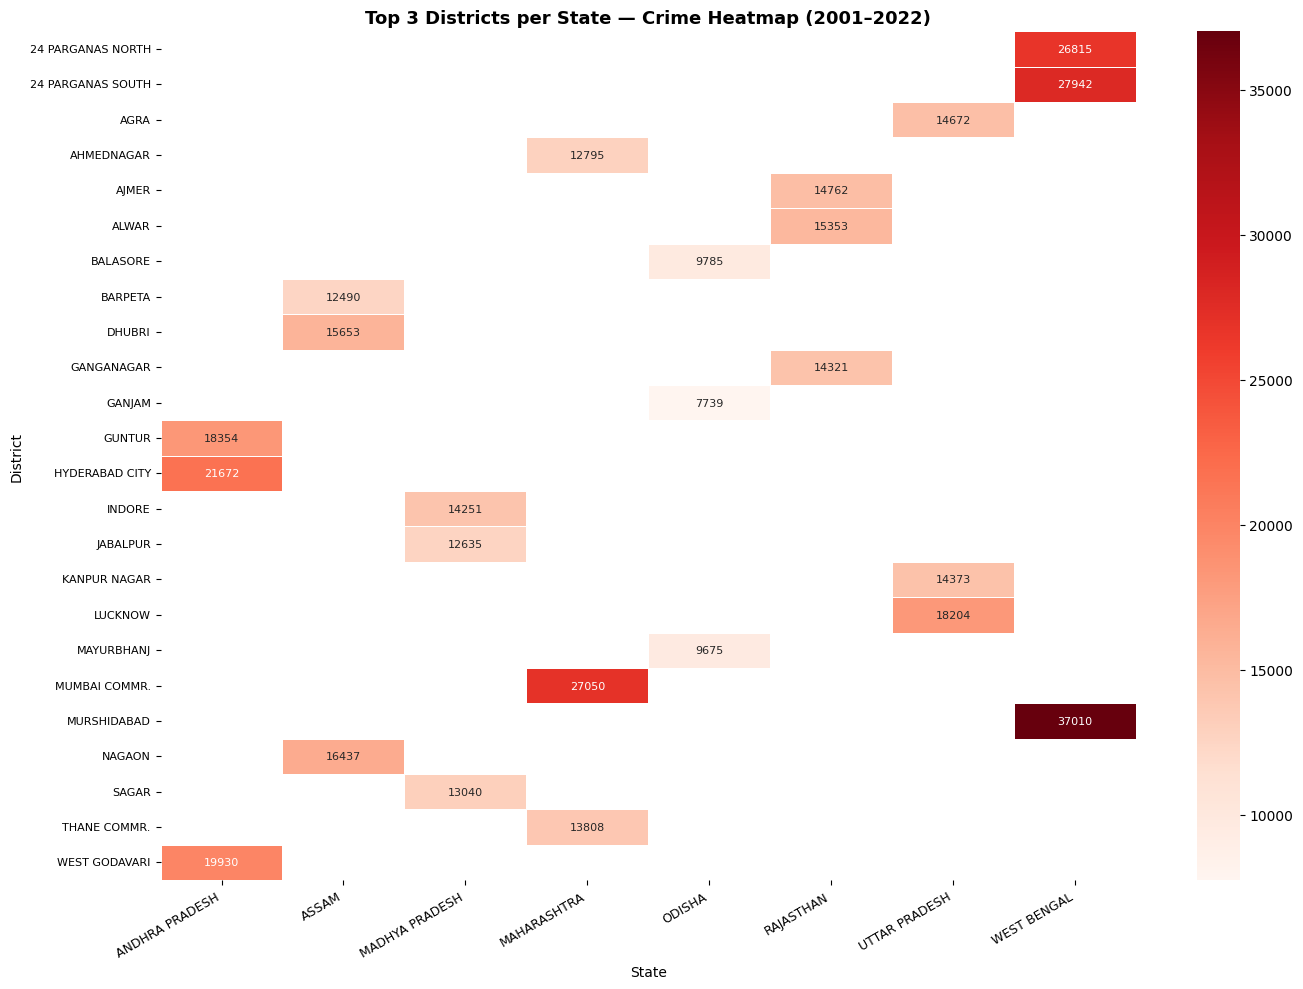

✅ Chart 8 improved & saved!


In [ ]:
# Better heatmap — har state ke TOP 3 districts
results = []

for state in top8_states:
    state_data = df_district_clean[
        df_district_clean['State'] == state
    ]
    top3 = state_data.groupby('District')['Total_Crimes']\
           .sum().nlargest(3).reset_index()
    top3['State'] = state
    results.append(top3)

df_top3_per_state = pd.concat(results, ignore_index=True)

# Pivot
pivot_improved = df_top3_per_state.pivot_table(
    index='District',
    columns='State',
    values='Total_Crimes',
    aggfunc='sum'
).fillna(0)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_improved,
            cmap='Reds',
            linewidths=0.5,
            annot=True,
            fmt='.0f',
            annot_kws={'size': 8},
            mask=pivot_improved == 0)  # 0 values hide karo

plt.title('Top 3 Districts per State — Crime Heatmap (2001–2022)',
          fontsize=13, fontweight='bold')
plt.xlabel('State')
plt.ylabel('District')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(folder + '../3_Charts/08_district_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 8 improved & saved!")

In [ ]:
# Exact count dekho
print("Total unique districts:",
      df_district_clean['District'].nunique())

print("\nTotal rows:", len(df_district_clean))

print("\nYear-wise district count:")
print(df_district_clean.groupby('Year')['District']\
      .nunique().reset_index())

print("\nSample district names:")
print(sorted(df_district_clean['District'].unique())[:30])

NameError: name 'df_district_clean' is not defined

In [ ]:
import pandas as pd

folder = '/content/drive/MyDrive/Crime-Project/1_Data/'

# Saved clean file se load karo
df_district_clean = pd.read_csv(
    folder + 'CLEAN_district_data.csv'
)

print("✅ Loaded!")
print("Total rows:", len(df_district_clean))
print("Unique districts:",
      df_district_clean['District'].nunique())
print("Unique states:",
      df_district_clean['State'].nunique())
print("\nYear-wise district count:")
print(df_district_clean.groupby('Year')['District']\
      .nunique().reset_index())
print("\nSample districts:")
print(sorted(df_district_clean['District']\
      .unique())[:30])

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Crime-Project/1_Data/CLEAN_district_data.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

folder = '/content/drive/MyDrive/Crime-Project/1_Data/'

# Saved clean file se load karo
df_district_clean = pd.read_csv(
    folder + 'CLEAN_district_data.csv'
)

print("✅ Loaded!")
print("Total rows:", len(df_district_clean))
print("Unique districts:",
      df_district_clean['District'].nunique())
print("Unique states:",
      df_district_clean['State'].nunique())
print("\nYear-wise district count:")
print(df_district_clean.groupby('Year')['District']\
      .nunique().reset_index())
print("\nSample districts:")
# Fix: Filter out NaN values before sorting to avoid TypeError
print(sorted(df_district_clean['District'].dropna().unique())[:30])

✅ Loaded!
Total rows: 11937
Unique districts: 1140
Unique states: 43

Year-wise district count:
    Year  District
0   2001       666
1   2002       669
2   2003       678
3   2004       679
4   2005       683
5   2006       690
6   2007       693
7   2008       710
8   2009       715
9   2010       726
10  2011       740
11  2012       758
12  2013       769
13  2014       781
14  2015       794
15  2022       913

Sample districts:
['24 PARGANAS NORTH', '24 PARGANAS SOUTH', 'A AND N ISLANDS', 'ADILABAD', 'AGAR', 'AGRA', 'AHMEDABAD CITY', 'AHMEDABAD COMMR.', 'AHMEDABAD RURAL', 'AHMEDNAGAR', 'AHWA-DANG', 'AIZAWL', 'AJMER', 'AKOLA', 'ALAPUZHA', 'ALIGARH', 'ALIPURDUAR', 'ALIRAJPUR', 'ALL DISTRICTS', 'ALLAHABAD', 'ALLURI SITHARAMA RAJU', 'ALMORA', 'ALWAR', 'AMBALA', 'AMBALA (RURAL)', 'AMBALA (URBAN)', 'AMBALA RURAL', 'AMBALA URBAN', 'AMBEDKAR NAGAR', 'AMETHI']


In [ ]:
# Exact count dekho
print("Total unique districts:",
      df_district_clean['District'].nunique())

print("\nTotal rows:", len(df_district_clean))

print("\nYear-wise district count:")
print(df_district_clean.groupby('Year')['District']\
      .nunique().reset_index())

print("\nSample district names:")
# Fix: Filter out NaN values before sorting to avoid TypeError
print(sorted(df_district_clean['District'].dropna().unique())[:30])

Total unique districts: 1140

Total rows: 11937

Year-wise district count:
    Year  District
0   2001       666
1   2002       669
2   2003       678
3   2004       679
4   2005       683
5   2006       690
6   2007       693
7   2008       710
8   2009       715
9   2010       726
10  2011       740
11  2012       758
12  2013       769
13  2014       781
14  2015       794
15  2022       913

Sample district names:
['24 PARGANAS NORTH', '24 PARGANAS SOUTH', 'A AND N ISLANDS', 'ADILABAD', 'AGAR', 'AGRA', 'AHMEDABAD CITY', 'AHMEDABAD COMMR.', 'AHMEDABAD RURAL', 'AHMEDNAGAR', 'AHWA-DANG', 'AIZAWL', 'AJMER', 'AKOLA', 'ALAPUZHA', 'ALIGARH', 'ALIPURDUAR', 'ALIRAJPUR', 'ALL DISTRICTS', 'ALLAHABAD', 'ALLURI SITHARAMA RAJU', 'ALMORA', 'ALWAR', 'AMBALA', 'AMBALA (RURAL)', 'AMBALA (URBAN)', 'AMBALA RURAL', 'AMBALA URBAN', 'AMBEDKAR NAGAR', 'AMETHI']


In [ ]:
# States duplicates dekho
print("All unique states:")
print(sorted(df_district_clean['State'].unique()))

All unique states:
['A & N ISLANDS', 'A&N ISLANDS', 'ANDAMAN AND NICOBAR ISLANDS', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH', 'D & N HAVELI', 'D&N HAVELI', 'DADRA AND NAGAR HAVELI AND DAMAN AND DIU', 'DAMAN & DIU', 'DELHI', 'DELHI UT', 'GOA', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'JAMMU & KASHMIR', 'JAMMU AND KASHMIR', 'JHARKHAND', 'KARNATAKA', 'KERALA', 'LADAKH', 'LAKSHADWEEP', 'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM', 'NAGALAND', 'ODISHA', 'PUDUCHERRY', 'PUNJAB', 'RAJASTHAN', 'SIKKIM', 'TAMIL NADU', 'TELANGANA', 'TRIPURA', 'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL']


In [ ]:
# State names standardize karo
df_district_clean['State'] = df_district_clean['State'].replace({
    'Delhi UT'       : 'DELHI',
    'Andhra Pradesh' : 'ANDHRA PRADESH',
    'Arunachal Pradesh': 'ARUNACHAL PRADESH',
    'Assam'          : 'ASSAM',
    'Bihar'          : 'BIHAR',
    'Chhattisgarh'   : 'CHHATTISGARH',
    'Goa'            : 'GOA',
    'Gujarat'        : 'GUJARAT',
    'Haryana'        : 'HARYANA',
    'Himachal Pradesh': 'HIMACHAL PRADESH',
    'Jammu & Kashmir': 'JAMMU & KASHMIR',
    'Jharkhand'      : 'JHARKHAND',
    'Karnataka'      : 'KARNATAKA',
    'Kerala'         : 'KERALA',
    'Madhya Pradesh' : 'MADHYA PRADESH',
    'Maharashtra'    : 'MAHARASHTRA',
    'Manipur'        : 'MANIPUR',
    'Meghalaya'      : 'MEGHALAYA',
    'Mizoram'        : 'MIZORAM',
    'Nagaland'       : 'NAGALAND',
    'Odisha'         : 'ODISHA',
    'Punjab'         : 'PUNJAB',
    'Puducherry'     : 'PUDUCHERRY',
    'Rajasthan'      : 'RAJASTHAN',
    'Sikkim'         : 'SIKKIM',
    'Tamil Nadu'     : 'TAMIL NADU',
    'Telangana'      : 'TELANGANA',
    'Tripura'        : 'TRIPURA',
    'Uttar Pradesh'  : 'UTTAR PRADESH',
    'Uttarakhand'    : 'UTTARAKHAND',
    'West Bengal'    : 'WEST BENGAL',
})

print("States after fix:",
      df_district_clean['State'].nunique())
print(sorted(df_district_clean['State'].unique()))

States after fix: 43
['A & N ISLANDS', 'A&N ISLANDS', 'ANDAMAN AND NICOBAR ISLANDS', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH', 'D & N HAVELI', 'D&N HAVELI', 'DADRA AND NAGAR HAVELI AND DAMAN AND DIU', 'DAMAN & DIU', 'DELHI', 'DELHI UT', 'GOA', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'JAMMU & KASHMIR', 'JAMMU AND KASHMIR', 'JHARKHAND', 'KARNATAKA', 'KERALA', 'LADAKH', 'LAKSHADWEEP', 'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM', 'NAGALAND', 'ODISHA', 'PUDUCHERRY', 'PUNJAB', 'RAJASTHAN', 'SIKKIM', 'TAMIL NADU', 'TELANGANA', 'TRIPURA', 'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL']


In [ ]:
# District names bhi standardize karo
df_district_clean['District'] = \
    df_district_clean['District'].str.strip().str.upper()

print("\nDistricts after fix:",
      df_district_clean['District'].nunique())

# Save karo
df_district_clean.to_csv(
    folder + 'CLEAN_district_data.csv',
    index=False
)
print("✅ Saved!")


Districts after fix: 1140
✅ Saved!


In [ ]:
print("All states after fix:")
for s in sorted(df_district_clean['State'].unique()):
    print(f"  '{s}'")

All states after fix:
  'A & N ISLANDS'
  'A&N ISLANDS'
  'ANDAMAN AND NICOBAR ISLANDS'
  'ANDHRA PRADESH'
  'ARUNACHAL PRADESH'
  'ASSAM'
  'BIHAR'
  'CHANDIGARH'
  'CHHATTISGARH'
  'D & N HAVELI'
  'D&N HAVELI'
  'DADRA AND NAGAR HAVELI AND DAMAN AND DIU'
  'DAMAN & DIU'
  'DELHI'
  'DELHI UT'
  'GOA'
  'GUJARAT'
  'HARYANA'
  'HIMACHAL PRADESH'
  'JAMMU & KASHMIR'
  'JAMMU AND KASHMIR'
  'JHARKHAND'
  'KARNATAKA'
  'KERALA'
  'LADAKH'
  'LAKSHADWEEP'
  'MADHYA PRADESH'
  'MAHARASHTRA'
  'MANIPUR'
  'MEGHALAYA'
  'MIZORAM'
  'NAGALAND'
  'ODISHA'
  'PUDUCHERRY'
  'PUNJAB'
  'RAJASTHAN'
  'SIKKIM'
  'TAMIL NADU'
  'TELANGANA'
  'TRIPURA'
  'UTTAR PRADESH'
  'UTTARAKHAND'
  'WEST BENGAL'


In [ ]:
# Saare duplicates fix karo
df_district_clean['State'] = df_district_clean['State'].replace({
    # Andaman
    'A & N ISLANDS'    : 'ANDAMAN & NICOBAR ISLANDS',
    'A&N ISLANDS'      : 'ANDAMAN & NICOBAR ISLANDS',
    'ANDAMAN AND NICOBAR ISLANDS': 'ANDAMAN & NICOBAR ISLANDS',

    # Dadra
    'D & N HAVELI'     : 'DADRA & NAGAR HAVELI',
    'D&N HAVELI'       : 'DADRA & NAGAR HAVELI',
    'DADRA AND NAGAR HAVELI AND DAMAN AND DIU': 'DADRA & NAGAR HAVELI',
    'DAMAN & DIU'      : 'DADRA & NAGAR HAVELI',

    # Delhi
    'DELHI UT'         : 'DELHI',

    # J&K
    'JAMMU AND KASHMIR': 'JAMMU & KASHMIR',
})

print(f"States after fix: {df_district_clean['State'].nunique()}")
print("\nAll states:")
for s in sorted(df_district_clean['State'].unique()):
    print(f"  '{s}'")

# Save karo
df_district_clean.to_csv(
    folder + 'CLEAN_district_data.csv',
    index=False
)
print("\n✅ Saved!")

States after fix: 36

All states:
  'ANDAMAN & NICOBAR ISLANDS'
  'ANDHRA PRADESH'
  'ARUNACHAL PRADESH'
  'ASSAM'
  'BIHAR'
  'CHANDIGARH'
  'CHHATTISGARH'
  'DADRA & NAGAR HAVELI'
  'DELHI'
  'GOA'
  'GUJARAT'
  'HARYANA'
  'HIMACHAL PRADESH'
  'JAMMU & KASHMIR'
  'JHARKHAND'
  'KARNATAKA'
  'KERALA'
  'LADAKH'
  'LAKSHADWEEP'
  'MADHYA PRADESH'
  'MAHARASHTRA'
  'MANIPUR'
  'MEGHALAYA'
  'MIZORAM'
  'NAGALAND'
  'ODISHA'
  'PUDUCHERRY'
  'PUNJAB'
  'RAJASTHAN'
  'SIKKIM'
  'TAMIL NADU'
  'TELANGANA'
  'TRIPURA'
  'UTTAR PRADESH'
  'UTTARAKHAND'
  'WEST BENGAL'

✅ Saved!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Ensure folder is defined
folder = '/content/drive/MyDrive/Crime-Project/1_Data/'

# Ensure df_main is loaded if the kernel was restarted or not run previously
df_main = pd.read_csv(folder + 'CLEAN_main_data.csv')

df_2001_2012 = df_main[
    (df_main['Year'] >= 2001) &
    (df_main['Year'] <= 2012)
]

yearly = df_2001_2012.groupby('Year')\
         ['Total_Crimes'].sum()

print("Year-wise crimes 2001-2012:")
print(yearly)
print(f"\nTotal: {yearly.sum():,}")

Year-wise crimes 2001-2012:
Year
2001    128537
2002    128972
2003    128142
2004    140072
2005    139333
2006    149742
2007    170196
2008    182757
2009    190617
2010    200534
2011    178529
2012    235025
Name: Total_Crimes, dtype: int64

Total: 1,972,456


In [ ]:
total_arrests = 3612040
total_crimes = 1972456
rate = (total_arrests / total_crimes) * 100
print(f"Arrest Rate: {rate:.1f}%")


Arrest Rate: 183.1%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

folder = '/content/drive/MyDrive/Crime-Project/1_Data/'

# Cyber data check
df_cyber = pd.read_csv(folder + 'CLEAN_cyber_data.csv')
df_2023 = pd.read_csv(folder + 'CLEAN_2023_detail.csv')

print("=== CYBER DATA ===")
print("Columns:", df_cyber.columns.tolist())
print("Shape:", df_cyber.shape)
print("\nFirst 3 rows:")
print(df_cyber.head(3))

print("\n=== 2023 DETAIL ===")
print("Columns:", df_2023.columns.tolist())
print("Shape:", df_2023.shape)
print("\nFirst 3 rows:")
print(df_2023.head(3))

print("\n=== CYBER TOTALS ===")
cyber_cols = ['Blackmailing', 'Stalking', 'Morphing',
              'Fake_Profile', 'Pornography', 'Other_Cyber', 'Total_Cyber']
for col in cyber_cols:
    if col in df_cyber.columns:
        print(f"{col}: {df_cyber[col].sum():,}")

print("\n=== 2023 TOTAL ===")
if 'Total_2023' in df_2023.columns:
    print(f"Total_2023: {df_2023['Total_2023'].sum():,}")
    print("\nTop 5 states:")
    print(df_2023.nlargest(5, 'Total_2023')[['State','Total_2023']])

=== CYBER DATA ===
Columns: ['State', 'Blackmailing', 'Pornography', 'Stalking', 'Morphing', 'Fake_Profile', 'Other_Cyber', 'Total_Cyber']
Shape: (36, 8)

First 3 rows:
               State  Blackmailing  Pornography  Stalking  Morphing  \
0     ANDHRA PRADESH            10           68       151         1   
1  ARUNACHAL PRADESH             0            0         0         0   
2              ASSAM            11           97         2        74   

   Fake_Profile  Other_Cyber  Total_Cyber  
0             0          329          559  
1             0            4            4  
2             0          285          469  

=== 2023 DETAIL ===
Columns: ['State', 'Total_2023']
Shape: (36, 2)

First 3 rows:
               State  Total_2023
0     ANDHRA PRADESH       22418
1  ARUNACHAL PRADESH         326
2              ASSAM       12070

=== CYBER TOTALS ===
Blackmailing: 304
Stalking: 1,358
Morphing: 505
Fake_Profile: 102
Pornography: 2,767
Other_Cyber: 14,474
Total_Cyber: 19,510

=== 20

In [ ]:
import pandas as pd
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

folder = '/content/drive/MyDrive/Crime-Project/1_Data/'

# Load the cleaned district data
df_district_clean = pd.read_csv(folder + 'CLEAN_district_data.csv')

# Now, the original code can run
df_district_clean['State'].value_counts()

Mounted at /content/drive


,count
State,
UTTAR PRADESH,1172
MADHYA PRADESH,838
MAHARASHTRA,726
BIHAR,710
TAMIL NADU,629
RAJASTHAN,618
ODISHA,565
GUJARAT,538
KARNATAKA,532


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import pandas as pd

folder = '/content/drive/MyDrive/Crime-Project/1_Data/'

df_arrested = pd.read_csv(folder + 'CLEAN_arrested_data.csv')

# Remove 'TOTAL' rows from 'State' column
df_arrested_clean = df_arrested[
    ~df_arrested['State'].str.upper().str.contains('TOTAL')
].copy()

# Remove 'TOTAL' rows from 'Crime_Head' column
df_arrested_clean = df_arrested_clean[
    ~df_arrested_clean['Crime_Head'].str.upper().str.contains('TOTAL')
].copy()

print("Columns:", df_arrested_clean.columns.tolist())
print("\nUnique States:")
print(sorted(df_arrested_clean['State'].unique()))

print("\nUnique Crime Heads:")
print(df_arrested_clean['Crime_Head'].unique())

print("\nYear-wise Total Arrests:")
print(df_arrested_clean.groupby('Year')['Persons_Arrested'].sum())

print(f"\nGrand Total (cleaned): {df_arrested_clean['Persons_Arrested'].sum():,}")

print("\nTop 5 Crime Heads by arrests (cleaned):")
print(df_arrested_clean.groupby('Crime_Head')['Persons_Arrested']\
      .sum().nlargest(5))

# Save the cleaned dataframe
df_arrested_clean.to_csv(folder + 'CLEAN_arrested_data.csv', index=False)
print("\n✅ CLEAN_arrested_data.csv updated with cleaned data!")

Columns: ['State', 'Crime_Head', 'Year', 'Persons_Arrested']

Unique States:
['A & N ISLANDS', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH', 'D & N HAVELI', 'DAMAN & DIU', 'DELHI', 'GOA', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'JAMMU & KASHMIR', 'JHARKHAND', 'KARNATAKA', 'KERALA', 'LAKSHADWEEP', 'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM', 'NAGALAND', 'ODISHA', 'PUDUCHERRY', 'PUNJAB', 'RAJASTHAN', 'SIKKIM', 'TAMIL NADU', 'TRIPURA', 'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL']

Unique Crime Heads:
['RAPE' 'KIDNAPPING AND ABDUCTION' 'DOWRY DEATHS'
 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY'
 'INSULT TO THE MODESTY OF WOMEN'
 'CRUELTY BY HUSBAND OR HIS RELATIVES (IPC SECTION 498A)'
 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRY' 'IMMORAL TRAFFIC (P) ACT'
 'DOWRY PROHIBITION ACT' 'INDECENT REPRESENTATION OF WOMEN (P) ACT'
 'COMMISSION OF SATI (P) ACT']

Year-wise Total Arrests:
Year
2001    243589
2002    247981
2

In [7]:
df_arrested = pd.read_csv(folder + 'CLEAN_arrested_data.csv')

print("Before:", len(df_arrested), "rows")
print(f"Total sum before: {df_arrested['Persons_Arrested'].sum():,}")

# TOTAL rows hatao
df_arrested = df_arrested[
    ~df_arrested['State'].str.upper().str.contains(
        'TOTAL', na=False
    )
].copy()

print("\nAfter:", len(df_arrested), "rows")
print("Total sum after:", f"{df_arrested['Persons_Arrested'].sum():,}")

# Verify
print("\nYear-wise check:")
print(df_arrested.groupby('Year')['Persons_Arrested'].sum())

# Save karo
df_arrested.to_csv(
    folder + 'CLEAN_arrested_data.csv',
    index=False
)
print("\n✅ File saved!")

Before: 4620 rows
Total sum before: 3,612,040

After: 4620 rows
Total sum after: 3,612,040

Year-wise check:
Year
2001    243589
2002    247981
2003    239200
2004    261322
2005    266955
2006    279823
2007    310808
2008    323510
2009    335336
2010    345339
2011    363802
2012    394375
Name: Persons_Arrested, dtype: int64

✅ File saved!


In [8]:
df_arr = pd.read_csv(folder + 'CLEAN_arrested_data.csv')
df_main = pd.read_csv(folder + 'CLEAN_main_data.csv')

yearly_arr = df_arr.groupby('Year')['Persons_Arrested'].sum()
yearly_crimes = df_main[
    df_main['Year'].between(2001, 2012)
].groupby('Year')['Total_Crimes'].sum()

rate = (yearly_arr / yearly_crimes * 100).round(1)
print("Year-wise Arrest Rate %:")
print(rate)

Year-wise Arrest Rate %:
Year
2001    189.5
2002    192.3
2003    186.7
2004    186.6
2005    191.6
2006    186.9
2007    182.6
2008    177.0
2009    175.9
2010    172.2
2011    203.8
2012    167.8
dtype: float64
